# I. Nhập dữ liệu

In [ ]:
# =========================================================
# 0. SETUP
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, List, Tuple, Optional

from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

RANDOM_STATE = 42
DATA_DIR = Path("/content/datathon-2026-round-1.zip")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/datathon-2026-round-1.zip"
OUTPUT_DIR = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(OUTPUT_DIR)

In [ ]:
import pandas as pd
from pathlib import Path

# Nếu bên trong zip có 1 folder con, cần chỉnh lại path cho đúng
DATA_DIR = Path(OUTPUT_DIR)  # hoặc "/content/data/ten_folder_con"

for file in os.listdir(DATA_DIR):
    if file.endswith(".csv"):
        file_path = os.path.join(DATA_DIR, file)
        df = pd.read_csv(file_path)
        print(file, df.shape)

fact_returns1.csv (39939, 33)
web_traffic.csv (3652, 7)
churn_status_summary_fixed.csv (4, 8)
fact_customer_clv_churn_segment_fixed.csv (90246, 64)
products.csv (2412, 8)
promo_segment_summary_fixed.csv (4, 19)
fact_web_traffic_daily1.csv (3652, 12)
fact_sales1.csv (714669, 44)
sales_reconciliation1.csv (3833, 7)
orders.csv (646945, 8)
customer_action_summary_fixed.csv (9, 11)
clv_segment_summary_fixed.csv (5, 19)
fact_reviews1.csv (113551, 33)
clv_summary_fixed.csv (12, 2)
shipments.csv (566067, 4)
sample_submission.csv (548, 3)
sales.csv (3833, 3)
payments.csv (646945, 4)
reviews.csv (113551, 7)
promo_usage_vs_clv_summary_fixed.csv (5, 15)
monthly_churn_1y_2y_3y_fixed.csv (378, 7)
promotions.csv (50, 10)
fact_inventory_monthly1.csv (60247, 27)
segment_description_fixed.csv (14, 4)
order_items.csv (714669, 7)
customers.csv (121930, 7)
rfm_segment_summary_fixed.csv (7, 19)
geography.csv (39948, 4)
churn_summary_1y_2y_3y_fixed.csv (11, 2)
new_customer_rate_by_year_2012_2022_fixed.csv (1

In [ ]:
# =========================================================
# 1. LOAD DATA (UPDATED WITH ROBUST DATE PARSING)
# =========================================================

DATA_DIR = Path(OUTPUT_DIR)

FILE_MAP = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

# Mapping các cột ngày dự kiến (Sẽ được xử lý case-insensitive)
EXPECTED_DATE_COLS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}

DTYPE_MAP = {
    "order_items": {"promo_id": "string", "promo_id_2": "string"},
    "promotions": {"promo_id": "string"}
}

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False))
    return df

def get_actual_date_cols(file_path: Path, table_name: str) -> List[str]:
    """Kiểm tra các cột thực tế trong CSV để khớp với EXPECTED_DATE_COLS (không phân biệt hoa thường)."""
    if table_name not in EXPECTED_DATE_COLS: return None

    # Đọc header của file CSV
    temp_df = pd.read_csv(file_path, nrows=0)
    actual_columns = temp_df.columns.tolist()

    matches = []
    for target in EXPECTED_DATE_COLS[table_name]:
        # Tìm cột trong file có tên giống (không phân biệt hoa thường)
        match = [c for c in actual_columns if c.lower() == target.lower()]
        if match: matches.append(match[0])

    return matches if matches else None

def load_one_table(name: str, file_name: str) -> pd.DataFrame:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        print(f"[WARNING] File không tồn tại: {file_path}")
        return pd.DataFrame()

    # Tự động tìm tên cột ngày thực tế trong file
    parse_dates = get_actual_date_cols(file_path, name)

    df = pd.read_csv(
        file_path,
        dtype=DTYPE_MAP.get(name, None),
        parse_dates=parse_dates,
        low_memory=False
    )
    df = standardize_columns(df)
    return df

def load_all_tables(file_map: Dict[str, str]) -> Dict[str, pd.DataFrame]:
    tables = {}
    for name, file_name in file_map.items():
        tables[name] = load_one_table(name, file_name)
    return tables

tables = load_all_tables(FILE_MAP)

for name, df in tables.items():
    print("=" * 40)
    print(f"{name}: {df.shape}")

products: (2412, 8)
customers: (121930, 7)
promotions: (50, 10)
geography: (39948, 4)
orders: (646945, 8)
order_items: (714669, 7)
payments: (646945, 4)
shipments: (566067, 4)
returns: (39939, 7)
reviews: (113551, 7)
sales: (3833, 3)
inventory: (60247, 17)
web_traffic: (3652, 7)


In [ ]:
def ensure_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    assert len(missing) == 0, f"[{name}] Missing columns: {missing}"

def assert_unique(df, keys, name):
    ensure_columns(df, keys, name)
    dup = df.duplicated(subset=keys).sum()
    assert dup == 0, f"[{name}] Duplicate key rows = {dup}"

def safe_divide(a, b):
    return np.where(b != 0, a / b, np.nan)

def add_date_parts(df, date_col, prefix=""):
    df = df.copy()
    df[f"{prefix}year"] = df[date_col].dt.year
    df[f"{prefix}month"] = df[date_col].dt.month
    df[f"{prefix}year_month"] = df[date_col].dt.to_period("M").astype(str)
    # Sử dụng normalize() để giữ kiểu Timestamp thay vì .dt.date (python date object) gây lỗi tính toán
    df[f"{prefix}date"] = df[date_col].dt.normalize()
    return df

# II. Xây các bảng dữ liệu để phân tích

## 2.1. Build fact_sales

In [ ]:
# Giải nén các bảng từ dictionary tables để sử dụng trực tiếp
products = tables['products']
customers = tables['customers']
promotions = tables['promotions']
geography = tables['geography']
orders = tables['orders']
order_items = tables['order_items']
returns = tables['returns']
reviews = tables['reviews']
inventory = tables['inventory']
web_traffic = tables['web_traffic']

# Kiểm tra cơ bản
assert_unique(products, ["product_id"], "products")
assert_unique(customers, ["customer_id"], "customers")
assert_unique(promotions, ["promo_id"], "promotions")
assert_unique(geography, ["zip"], "geography")
assert_unique(orders, keys=["order_id"], name="orders")

ensure_columns(order_items, ["order_id", "product_id", "quantity", "unit_price", "discount_amount"], "order_items")
ensure_columns(orders, ["order_id", "order_date", "customer_id", "zip"], "orders")
ensure_columns(products, ["product_id", "product_name", "category", "segment", "price", "cogs"], "products")

In [ ]:
def build_fact_sales(order_items, orders, products, customers, geography, promotions):
    fact = order_items.copy()

    # Chuẩn hóa promo_id
    if "promo_id" in fact.columns:
        fact["promo_id"] = fact["promo_id"].astype("string")
    if "promo_id_2" in fact.columns:
        fact["promo_id_2"] = fact["promo_id_2"].astype("string")
    if "promo_id" in promotions.columns:
        promotions["promo_id"] = promotions["promo_id"].astype("string")

    # Join orders
    order_cols = ["order_id", "order_date", "customer_id", "zip", "order_status", "payment_method", "device_type", "order_source"]
    order_cols = [c for c in order_cols if c in orders.columns]
    fact = fact.merge(orders[order_cols], on="order_id", how="left")

    # Join products
    product_cols = ["product_id", "product_name", "category", "segment", "size", "color", "price", "cogs"]
    product_cols = [c for c in product_cols if c in products.columns]
    fact = fact.merge(products[product_cols], on="product_id", how="left")

    # Join customers
    customer_cols = ["customer_id", "city", "signup_date", "gender", "age_group", "acquisition_channel"]
    customer_cols = [c for c in customer_cols if c in customers.columns]
    if len(customer_cols) > 0:
        fact = fact.merge(customers[customer_cols], on="customer_id", how="left", suffixes=("", "_customer"))

    # Join geography qua zip giao hàng
    geo_cols = ["zip", "city", "region", "district"]
    geo_cols = [c for c in geo_cols if c in geography.columns]
    if len(geo_cols) > 0:
        geo = geography[geo_cols].copy().rename(columns={"city": "shipping_city"})
        fact = fact.merge(geo, on="zip", how="left")

    # Join promotions qua promo_id chính
    promo_cols = ["promo_id", "promo_name", "promo_type", "discount_value", "promo_channel", "stackable_flag"]
    promo_cols = [c for c in promo_cols if c in promotions.columns]
    if "promo_id" in fact.columns and len(promo_cols) > 0:
        fact = fact.merge(promotions[promo_cols], on="promo_id", how="left")

    # Rename
    if "price" in fact.columns:
        fact = fact.rename(columns={"price": "list_price"})
    if "cogs" in fact.columns:
        fact = fact.rename(columns={"cogs": "unit_cogs"})
    if "unit_price" in fact.columns:
        fact = fact.rename(columns={"unit_price": "selling_unit_price"})

    # Measures
    fact["gross_revenue_before_discount"] = fact["quantity"] * fact["selling_unit_price"]
    fact["net_revenue"] = fact["gross_revenue_before_discount"] - fact["discount_amount"]
    fact["cogs_amount"] = fact["quantity"] * fact["unit_cogs"]
    fact["gross_profit"] = fact["net_revenue"] - fact["cogs_amount"]
    fact["gross_margin"] = safe_divide(fact["gross_profit"], fact["net_revenue"])
    fact["discount_rate"] = safe_divide(fact["discount_amount"], fact["gross_revenue_before_discount"])
    fact["has_promo"] = fact["promo_id"].notna().astype(int) if "promo_id" in fact.columns else 0

    # Date parts
    fact = add_date_parts(fact, "order_date", prefix="order_")

    return fact

fact_sales = build_fact_sales(order_items, orders, products, customers, geography, promotions)
fact_sales.head()

,order_id,product_id,quantity,selling_unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,list_price,unit_cogs,city,signup_date,gender,age_group,acquisition_channel,shipping_city,region,district,promo_name,promo_type,discount_value,promo_channel,stackable_flag,gross_revenue_before_discount,net_revenue,cogs_amount,gross_profit,gross_margin,discount_rate,has_promo,order_year,order_month,order_year_month
0,1,2400,7,"1,138.2200",0.0000,<NA>,<NA>,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.2611","1,053.7980",Hanoi,2020-06-06,Female,35-44,social_media,Hanoi,East,District #02,NaN,NaN,NaN,NaN,NaN,"7,967.5400","7,967.5400","7,376.5861",590.9539,0.0742,0.0000,0,2012,7,2012-07
1,2,609,7,"10,166.2500",0.0000,<NA>,<NA>,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.5710","8,987.7042",Phu Ly,2021-11-03,Female,18-24,social_media,Phu Ly,East,District #02,NaN,NaN,NaN,NaN,NaN,"71,163.7500","71,163.7500","62,913.9296","8,249.8204",0.1159,0.0000,0,2012,7,2012-07
2,3,396,3,"11,220.3300",0.0000,<NA>,<NA>,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.4287","10,091.0123",Lao Cai,2020-09-18,Female,35-44,direct,Lao Cai,East,District #02,NaN,NaN,NaN,NaN,NaN,"33,660.9900","33,660.9900","30,273.0368","3,387.9532",0.1006,0.0000,0,2012,7,2012-07
3,4,635,5,"10,639.2500",0.0000,<NA>,<NA>,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.2206","9,205.4305",Son Tay,2016-05-29,Male,45-54,direct,Son Tay,East,District #02,NaN,NaN,NaN,NaN,NaN,"53,196.2500","53,196.2500","46,027.1524","7,169.0976",0.1348,0.0000,0,2012,7,2012-07
4,6,1935,1,"1,597.8400",0.0000,<NA>,<NA>,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.9115","1,048.6964",Uong Bi,2017-07-11,Male,18-24,social_media,Uong Bi,East,District #02,NaN,NaN,NaN,NaN,NaN,"1,597.8400","1,597.8400","1,048.6964",549.1436,0.3437,0.0000,0,2012,7,2012-07


In [ ]:
# Check nhanh fact_sales
print("fact_sales shape:", fact_sales.shape)
print("Missing order after join:", fact_sales["order_date"].isna().sum())
print("Missing product after join:", fact_sales["product_name"].isna().sum())
print("Missing customer after join:", fact_sales["customer_id"].isna().sum())
print("Rows with negative revenue:", (fact_sales["net_revenue"] < 0).sum())
print("Rows with discount > gross revenue:", (fact_sales["discount_amount"] > fact_sales["gross_revenue_before_discount"]).sum())

fact_sales shape: (714669, 44)
Missing order after join: 0
Missing product after join: 0
Missing customer after join: 0
Rows with negative revenue: 0
Rows with discount > gross revenue: 0


## 2.2. Build fact_returns

In [ ]:
assert_unique(returns, ["return_id"], "returns")
ensure_columns(returns, ["return_id", "order_id", "product_id", "return_date", "return_quantity", "refund_amount"], "returns")

In [ ]:
def build_fact_returns(returns, orders, products, customers, geography):
    fact = returns.copy()

    # Join orders
    order_cols = ["order_id", "order_date", "customer_id", "zip", "order_status", "payment_method", "device_type", "order_source"]
    order_cols = [c for c in order_cols if c in orders.columns]
    fact = fact.merge(orders[order_cols], on="order_id", how="left")

    # Join products
    product_cols = ["product_id", "product_name", "category", "segment", "size", "color", "price", "cogs"]
    product_cols = [c for c in product_cols if c in products.columns]
    fact = fact.merge(products[product_cols], on="product_id", how="left")

    # Join customers
    customer_cols = ["customer_id", "city", "signup_date", "gender", "age_group", "acquisition_channel"]
    customer_cols = [c for c in customer_cols if c in customers.columns]
    if len(customer_cols) > 0:
        fact = fact.merge(customers[customer_cols], on="customer_id", how="left", suffixes=("", "_customer"))

    # Join geography
    geo_cols = ["zip", "city", "region", "district"]
    geo_cols = [c for c in geo_cols if c in geography.columns]
    if len(geo_cols) > 0:
        geo = geography[geo_cols].copy().rename(columns={"city": "shipping_city"})
        fact = fact.merge(geo, on="zip", how="left")

    # Date parts
    fact = add_date_parts(fact, "return_date", prefix="return_")

    # Derived metrics - Đảm bảo cả hai đều là datetime64[ns]
    if "order_date" in fact.columns and "return_date" in fact.columns:
        fact["order_date"] = pd.to_datetime(fact["order_date"])
        fact["return_date"] = pd.to_datetime(fact["return_date"])
        fact["days_to_return"] = (fact["return_date"] - fact["order_date"]).dt.days

    return fact

fact_returns = build_fact_returns(returns, orders, products, customers, geography)
display(fact_returns.head())

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,city,signup_date,gender,age_group,acquisition_channel,shipping_city,region,district,return_year,return_month,return_year_month,days_to_return
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.0100",2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.5710","8,987.7042",Phu Ly,2021-11-03,Female,18-24,social_media,Phu Ly,East,District #02,2012,7,2012-07,21
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.3700",2012-07-05,6037,17033,returned,credit_card,desktop,social_media,SaigonCore YY-57,GenZ,Trendy,L,orange,"2,656.2321","1,842.6282",Viet Tri,2021-04-13,Female,25-34,social_media,Viet Tri,East,District #05,2012,7,2012-07,11
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.9500",2012-07-04,3666,18944,returned,credit_card,desktop,organic_search,VietMotion UC-07,Streetwear,Everyday,XL,yellow,"5,399.8259","3,136.7589",Hanoi,2021-03-30,Male,25-34,social_media,Hanoi,East,District #04,2012,7,2012-07,12
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.7500",2012-07-06,72063,24212,returned,credit_card,mobile,organic_search,VietMode RP-41,Outdoor,Activewear,M,yellow,"1,802.1150","1,575.7694",Bac Ninh,2019-08-04,Female,45-54,organic_search,Bac Ninh,East,District #19,2012,7,2012-07,5
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.7600",2012-07-06,72063,24212,returned,credit_card,mobile,organic_search,VietMode RP-42,Outdoor,Activewear,L,red,"1,802.1150","1,309.0563",Bac Ninh,2019-08-04,Female,45-54,organic_search,Bac Ninh,East,District #19,2012,7,2012-07,19


In [ ]:
print("fact_returns shape:", fact_returns.shape)
print("Missing order info:", fact_returns["order_date"].isna().sum())
print("Missing product info:", fact_returns["product_name"].isna().sum())
print("Rows with return_date < order_date:", (fact_returns["return_date"] < fact_returns["order_date"]).sum())
print("Rows with negative refund:", (fact_returns["refund_amount"] < 0).sum())

fact_returns shape: (39939, 33)
Missing order info: 0
Missing product info: 0
Rows with return_date < order_date: 0
Rows with negative refund: 0


## 2.3. Build fact_reviews

In [ ]:
assert_unique(reviews, ["review_id"], "reviews")
ensure_columns(reviews, ["review_id", "order_id", "product_id", "customer_id", "review_date", "rating"], "reviews")

In [ ]:
def build_fact_reviews(reviews, orders, products, customers, geography):
    fact = reviews.copy()

    # Join orders
    order_cols = ["order_id", "order_date", "customer_id", "zip", "order_status", "payment_method", "device_type", "order_source"]
    order_cols = [c for c in order_cols if c in orders.columns]
    fact = fact.merge(orders[order_cols], on="order_id", how="left", suffixes=("", "_order"))

    # Join products
    product_cols = ["product_id", "product_name", "category", "segment", "size", "color", "price", "cogs"]
    product_cols = [c for c in product_cols if c in products.columns]
    fact = fact.merge(products[product_cols], on="product_id", how="left")

    # Join customers
    customer_cols = ["customer_id", "city", "signup_date", "gender", "age_group", "acquisition_channel"]
    customer_cols = [c for c in customer_cols if c in customers.columns]
    if len(customer_cols) > 0:
        fact = fact.merge(customers[customer_cols], on="customer_id", how="left", suffixes=("", "_customer"))

    # Join geography
    geo_cols = ["zip", "city", "region", "district"]
    geo_cols = [c for c in geo_cols if c in geography.columns]
    if len(geo_cols) > 0:
        geo = geography[geo_cols].copy().rename(columns={"city": "shipping_city"})
        fact = fact.merge(geo, on="zip", how="left")

    # Date parts
    fact = add_date_parts(fact, "review_date", prefix="review_")

    # Derived metrics
    if "order_date" in fact.columns:
        fact["days_to_review"] = (fact["review_date"] - fact["order_date"]).dt.days

    return fact

fact_reviews = build_fact_reviews(reviews, orders, products, customers, geography)
fact_reviews.head()

,review_id,order_id,product_id,customer_id,review_date,rating,review_title,order_date,customer_id_order,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,city,signup_date,gender,age_group,acquisition_channel,shipping_city,region,district,review_year,review_month,review_year_month,days_to_review
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.2611","1,053.7980",Hanoi,2020-06-06,Female,35-44,social_media,Hanoi,East,District #02,2012,7,2012-07,20
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.4287","10,091.0123",Lao Cai,2020-09-18,Female,35-44,direct,Lao Cai,East,District #02,2012,8,2012-08,30
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality,2012-07-06,49101,5262,delivered,paypal,desktop,organic_search,VietMode RP-23,Outdoor,Activewear,XL,black,"4,093.7400","2,673.2122",Thai Nguyen,2022-01-22,Female,45-54,email_campaign,Thai Nguyen,East,District #01,2012,7,2012-07,17
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality,2012-07-05,41028,7830,delivered,cod,mobile,social_media,VietMode UR-01,Streetwear,Standard,S,pink,"5,164.7400","2,678.9506",Lao Cai,2022-09-14,Male,25-34,email_campaign,Lao Cai,East,District #03,2012,8,2012-08,31
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall,2012-07-05,42030,8016,delivered,cod,tablet,email_campaign,VietMotion UE-26,Streetwear,Performance,S,orange,"4,441.3230","3,680.9685",Lao Cai,2020-03-09,Male,35-44,paid_search,Lao Cai,East,District #04,2012,7,2012-07,12


In [ ]:
print("fact_reviews shape:", fact_reviews.shape)
print("Missing order info:", fact_reviews["order_date"].isna().sum())
print("Missing product info:", fact_reviews["product_name"].isna().sum())
print("Rows with invalid rating:", (~fact_reviews["rating"].between(1, 5)).sum())
print("Rows with review_date < order_date:", (fact_reviews["review_date"] < fact_reviews["order_date"]).sum())

fact_reviews shape: (113551, 33)
Missing order info: 0
Missing product info: 0
Rows with invalid rating: 0
Rows with review_date < order_date: 0


## 2.4. Check đối soát đơn giản giữa sales fact và sales.csv

In [ ]:
def reconcile_sales_daily(fact_sales, sales):
    if sales.empty:
        return pd.DataFrame()

    # Group fact_sales by date
    sales_fact_daily = (
        fact_sales.groupby("order_date", as_index=False)
        .agg(
            fact_revenue=("net_revenue", "sum"),
            fact_cogs=("cogs_amount", "sum")
        )
        .rename(columns={"order_date": "date"})
    )

    sales_daily = sales.copy()

    # Fix: Ensure both 'date' columns are datetime64[ns] to avoid merge conflict
    sales_fact_daily['date'] = pd.to_datetime(sales_fact_daily['date'])
    sales_daily['date'] = pd.to_datetime(sales_daily['date'])

    recon = sales_daily.merge(sales_fact_daily, on="date", how="outer")

    # Calculate differences
    recon["revenue_diff"] = recon["revenue"] - recon["fact_revenue"]
    recon["cogs_diff"] = recon["cogs"] - recon["fact_cogs"]

    return recon

sales_recon = reconcile_sales_daily(fact_sales, tables["sales"])
display(sales_recon.head())

,date,revenue,cogs,fact_revenue,fact_cogs,revenue_diff,cogs_diff
0,2012-07-04,"5,123,547.9400","3,982,991.1900","5,123,547.9400","3,982,991.1894",0.0000,0.0006
1,2012-07-05,"2,751,773.4500","2,150,580.2300","2,751,773.4500","2,150,580.2338",0.0000,-0.0038
2,2012-07-06,"3,054,029.4200","2,517,632.8400","3,054,029.4200","2,517,632.8434",0.0000,-0.0034
3,2012-07-07,"2,667,930.9400","2,108,246.6200","2,667,930.9400","2,108,246.6206",0.0000,-0.0006
4,2012-07-08,"2,360,851.9000","1,808,622.7900","2,360,851.9000","1,808,622.7949",0.0000,-0.0049


In [ ]:
from pathlib import Path

# Ensure OUTPUT_DIR is a Path object
save_path = Path(OUTPUT_DIR)

fact_sales.to_csv(save_path / "fact_sales1.csv", index=False)
fact_returns.to_csv(save_path / "fact_returns1.csv", index=False)
fact_reviews.to_csv(save_path / "fact_reviews1.csv", index=False)
fact_inventory_monthly.to_csv(save_path / "fact_inventory_monthly1.csv", index=False)
fact_web_traffic_daily.to_csv(save_path / "fact_web_traffic_daily1.csv", index=False)

if not sales_recon.empty:
    sales_recon.to_csv(save_path / "sales_reconciliation1.csv", index=False)

print(f"Đã lưu toàn bộ fact tables vào: {save_path}")

Đã lưu toàn bộ fact tables vào: /content/data


In [ ]:
fact_sales = pd.read_csv("/content/data/fact_sales1.csv", parse_dates=["order_date"])
fact_returns = pd.read_csv("/content/data/fact_returns1.csv", parse_dates=["order_date", "return_date"])
fact_reviews = pd.read_csv("/content/data/fact_reviews1.csv", parse_dates=["order_date", "review_date"])
fact_inventory_monthly = pd.read_csv("/content/data/fact_inventory_monthly1.csv", parse_dates=["snapshot_date"])
fact_web_traffic_daily = pd.read_csv("/content/data/fact_web_traffic_daily1.csv", parse_dates=["date"])

# Nếu year_month bị load thành object thì giữ nguyên cũng được
fact_sales.head()

,order_id,product_id,quantity,selling_unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,list_price,unit_cogs,city,signup_date,gender,age_group,acquisition_channel,shipping_city,region,district,promo_name,promo_type,discount_value,promo_channel,stackable_flag,gross_revenue_before_discount,net_revenue,cogs_amount,gross_profit,gross_margin,discount_rate,has_promo,order_year,order_month,order_year_month
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.2611","1,053.7980",Hanoi,2020-06-06,Female,35-44,social_media,Hanoi,East,District #02,NaN,NaN,NaN,NaN,NaN,"7,967.5400","7,967.5400","7,376.5861",590.9539,0.0742,0.0000,0,2012,7,2012-07
1,2,609,7,"10,166.2500",0.0000,NaN,NaN,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.5710","8,987.7042",Phu Ly,2021-11-03,Female,18-24,social_media,Phu Ly,East,District #02,NaN,NaN,NaN,NaN,NaN,"71,163.7500","71,163.7500","62,913.9296","8,249.8204",0.1159,0.0000,0,2012,7,2012-07
2,3,396,3,"11,220.3300",0.0000,NaN,NaN,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.4287","10,091.0123",Lao Cai,2020-09-18,Female,35-44,direct,Lao Cai,East,District #02,NaN,NaN,NaN,NaN,NaN,"33,660.9900","33,660.9900","30,273.0368","3,387.9532",0.1006,0.0000,0,2012,7,2012-07
3,4,635,5,"10,639.2500",0.0000,NaN,NaN,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.2206","9,205.4305",Son Tay,2016-05-29,Male,45-54,direct,Son Tay,East,District #02,NaN,NaN,NaN,NaN,NaN,"53,196.2500","53,196.2500","46,027.1524","7,169.0976",0.1348,0.0000,0,2012,7,2012-07
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.9115","1,048.6964",Uong Bi,2017-07-11,Male,18-24,social_media,Uong Bi,East,District #02,NaN,NaN,NaN,NaN,NaN,"1,597.8400","1,597.8400","1,048.6964",549.1436,0.3437,0.0000,0,2012,7,2012-07


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def safe_divide(a, b):
    return np.where(b != 0, a / b, np.nan)

def plot_top_bar(df, x_col, y_col, title="", n=10, ascending=False):
    plot_df = df.sort_values(y_col, ascending=ascending).head(n) if ascending else df.sort_values(y_col, ascending=False).head(n)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x=y_col, y=x_col)
    plt.title(title)
    plt.show()

def plot_line(df, x_col, y_col, title="", rotate_xticks=False):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df.sort_values(x_col), x=x_col, y=y_col)
    plt.title(title)
    if rotate_xticks:
        plt.xticks(rotation=45)
    plt.show()

def add_label(df, col_name, bins, labels):
    df = df.copy()
    df[col_name] = pd.cut(df[col_name], bins=bins, labels=labels, include_lowest=True)
    return df

def quick_metric_card(name, value):
    print(f"{name}: {value:,.4f}" if isinstance(value, (int, float, np.number)) else f"{name}: {value}")

def check_col(df, col):
    return col in df.columns

def mode_or_nan(series):
    s = series.dropna()
    return s.mode().iloc[0] if len(s) > 0 and len(s.mode()) > 0 else np.nan

def convert_date_cols(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# III. Phân tích customer

In [ ]:
# =========================================================
# 12. PHÂN TÍCH CUSTOMER - FIXED TO RUN AFTER CURRENT NOTEBOOK
# CLV | New Customers | Churn 1Y/2Y/3Y | Funnel | Segmentation | Promo vs CLV
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---------------------------------------------------------
# 12.0 FIX / OVERRIDE HELPER FUNCTIONS
# ---------------------------------------------------------

def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


def safe_divide(a, b):
    """
    Chia an toàn cho cả Series và scalar.
    Tránh lỗi khi mẫu số là 0 hoặc là một số đơn lẻ.
    """
    if np.isscalar(a) and np.isscalar(b):
        return np.nan if b == 0 else a / b

    a = pd.to_numeric(a, errors="coerce")

    if np.isscalar(b):
        return a / np.nan if b == 0 else a / b

    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def mode_or_nan(series):
    """
    Lấy mode cho biến phân loại.
    Nếu toàn bộ giá trị rỗng thì trả về NaN.
    """
    s = series.dropna()
    if len(s) == 0:
        return np.nan

    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan


def convert_date_cols(df, cols):
    """
    Chuyển các cột ngày về datetime nếu cột tồn tại.
    """
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def plot_top_bar(df, x_col, y_col, title="", n=10, ascending=False):
    """
    Vẽ bar chart ngang theo đúng style notebook hiện tại.
    x_col là biến phân loại hiển thị trên trục y.
    y_col là KPI hiển thị trên trục x.
    """
    if df.empty:
        print(f"[SKIP] {title}: DataFrame rỗng.")
        return

    plot_df = df.sort_values(y_col, ascending=ascending).head(n)

    plt.figure(figsize=(10, max(5, n * 0.35)))
    sns.barplot(data=plot_df, x=y_col, y=x_col)
    plt.title(title)
    plt.xlabel(y_col)
    plt.ylabel(x_col)
    plt.tight_layout()
    plt.show()


def plot_line(df, x_col, y_col, title="", rotate_xticks=False, hue=None):
    """
    Vẽ line chart.
    """
    if df.empty:
        print(f"[SKIP] {title}: DataFrame rỗng.")
        return

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df.sort_values(x_col), x=x_col, y=y_col, hue=hue, marker="o")
    plt.title(title)
    if rotate_xticks:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def quick_metric_card(name, value):
    if isinstance(value, (int, float, np.number)):
        print(f"{name}: {value:,.4f}")
    else:
        print(f"{name}: {value}")


def score_by_rank(series, high_good=True):
    """
    Chấm điểm 1-5 theo percentile.
    high_good=True: giá trị càng cao càng tốt.
    high_good=False: giá trị càng thấp càng tốt, dùng cho Recency.
    """
    s = pd.to_numeric(series, errors="coerce")
    pct = s.rank(pct=True, method="average")

    if not high_good:
        pct = 1 - pct + 1e-9

    score = pd.cut(
        pct,
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0000001],
        labels=[1, 2, 3, 4, 5],
        include_lowest=True
    )

    return score.astype(float)


# ---------------------------------------------------------
# 12.1 LOAD / RECOVER OBJECTS IF NEEDED
# ---------------------------------------------------------

OUTPUT_DIR = Path(OUTPUT_DIR)

def load_csv_if_needed(var_name, file_name, parse_dates=None):
    """
    Nếu biến đã tồn tại trong runtime thì dùng lại.
    Nếu chưa tồn tại thì load từ OUTPUT_DIR.
    """
    if var_name in globals():
        return globals()[var_name]

    file_path = OUTPUT_DIR / file_name
    if file_path.exists():
        return pd.read_csv(file_path, parse_dates=parse_dates, low_memory=False)

    print(f"[WARNING] Không tìm thấy biến {var_name} và cũng không thấy file {file_path}")
    return pd.DataFrame()


def get_table_from_tables_or_csv(table_name, file_name, parse_dates=None):
    """
    Ưu tiên lấy bảng từ dictionary tables của notebook.
    Nếu không có thì đọc trực tiếp CSV trong OUTPUT_DIR.
    """
    if "tables" in globals() and table_name in tables:
        return tables[table_name].copy()

    file_path = OUTPUT_DIR / file_name
    if file_path.exists():
        return pd.read_csv(file_path, parse_dates=parse_dates, low_memory=False)

    print(f"[WARNING] Không tìm thấy bảng {table_name}")
    return pd.DataFrame()


# Các fact table đã được notebook tạo ở trên
fact_sales = load_csv_if_needed("fact_sales", "fact_sales1.csv", parse_dates=["order_date"])
fact_returns = load_csv_if_needed("fact_returns", "fact_returns1.csv", parse_dates=["order_date", "return_date"])
fact_reviews = load_csv_if_needed("fact_reviews", "fact_reviews1.csv", parse_dates=["order_date", "review_date"])
fact_web_traffic_daily = load_csv_if_needed("fact_web_traffic_daily", "fact_web_traffic_daily1.csv", parse_dates=["date"])

# Bảng raw cần thêm
customers = get_table_from_tables_or_csv("customers", "customers.csv", parse_dates=["signup_date"])
orders = get_table_from_tables_or_csv("orders", "orders.csv", parse_dates=["order_date"])
payments = get_table_from_tables_or_csv("payments", "payments.csv")
shipments = get_table_from_tables_or_csv("shipments", "shipments.csv", parse_dates=["ship_date", "delivery_date"])

# Chuẩn hóa datetime
fact_sales = convert_date_cols(fact_sales, ["order_date", "signup_date"])
fact_returns = convert_date_cols(fact_returns, ["order_date", "return_date", "signup_date"])
fact_reviews = convert_date_cols(fact_reviews, ["order_date", "review_date", "signup_date"])
fact_web_traffic_daily = convert_date_cols(fact_web_traffic_daily, ["date"])
customers = convert_date_cols(customers, ["signup_date"])
orders = convert_date_cols(orders, ["order_date"])
shipments = convert_date_cols(shipments, ["ship_date", "delivery_date"])

print_section("CHECK INPUT TABLES")
print("fact_sales:", fact_sales.shape)
print("fact_returns:", fact_returns.shape)
print("fact_reviews:", fact_reviews.shape)
print("fact_web_traffic_daily:", fact_web_traffic_daily.shape)
print("customers:", customers.shape)
print("orders:", orders.shape)
print("payments:", payments.shape)
print("shipments:", shipments.shape)


CHECK INPUT TABLES
fact_sales: (714669, 44)
fact_returns: (39939, 33)
fact_reviews: (113551, 33)
fact_web_traffic_daily: (3652, 12)
customers: (121930, 7)
orders: (646945, 8)
payments: (646945, 4)
shipments: (566067, 4)


In [ ]:
# =========================================================
# 12.2 BUILD FACT_ORDER
# Grain: 1 dòng = 1 order_id
# =========================================================

def build_fact_order_customer_level(fact_sales, fact_returns, fact_reviews, payments, shipments):
    fs = fact_sales.copy()

    # Đảm bảo các cột số đúng định dạng
    numeric_cols = [
        "quantity", "selling_unit_price", "discount_amount",
        "gross_revenue_before_discount", "net_revenue",
        "cogs_amount", "gross_profit", "has_promo"
    ]
    for col in numeric_cols:
        if col in fs.columns:
            fs[col] = pd.to_numeric(fs[col], errors="coerce").fillna(0)

    fs["order_date"] = pd.to_datetime(fs["order_date"], errors="coerce")

    # -----------------------------------------------------
    # Dimension ở cấp order
    # -----------------------------------------------------
    order_dim_cols = [
        "customer_id", "order_date", "order_status", "payment_method",
        "device_type", "order_source", "zip", "shipping_city", "region",
        "district", "city", "gender", "age_group", "acquisition_channel",
        "signup_date"
    ]
    order_dim_cols = [c for c in order_dim_cols if c in fs.columns]

    order_dim = (
        fs.groupby("order_id", as_index=False)[order_dim_cols]
        .first()
    )

    # -----------------------------------------------------
    # Metrics từ fact_sales
    # net_revenue trong notebook đã đúng:
    # net_revenue = quantity * selling_unit_price - discount_amount
    # -----------------------------------------------------
    order_metrics = (
        fs.groupby("order_id", as_index=False)
        .agg(
            total_quantity=("quantity", "sum"),
            total_line_items=("product_id", "count"),
            unique_products=("product_id", "nunique"),
            unique_categories=("category", "nunique") if "category" in fs.columns else ("product_id", "nunique"),
            gross_revenue_before_discount=("gross_revenue_before_discount", "sum"),
            discount_amount=("discount_amount", "sum"),
            net_product_revenue=("net_revenue", "sum"),
            cogs_amount=("cogs_amount", "sum"),
            gross_profit_before_refund=("gross_profit", "sum"),
            has_promo=("has_promo", "max")
        )
    )

    fact_order = order_dim.merge(order_metrics, on="order_id", how="left")

    # -----------------------------------------------------
    # Join payments
    # -----------------------------------------------------
    if not payments.empty and "order_id" in payments.columns:
        pay = payments.copy()
        pay_cols = [c for c in ["order_id", "payment_value", "installments", "payment_method"] if c in pay.columns]
        pay = pay[pay_cols].drop_duplicates("order_id")

        fact_order = fact_order.merge(
            pay,
            on="order_id",
            how="left",
            suffixes=("", "_payment")
        )

    # -----------------------------------------------------
    # Join shipments
    # shipping_fee là phí vận chuyển.
    # Nếu miễn phí thì bằng 0 theo mô tả dữ liệu.
    # -----------------------------------------------------
    if not shipments.empty and "order_id" in shipments.columns:
        shp = shipments.copy()
        shp = convert_date_cols(shp, ["ship_date", "delivery_date"])
        shp_cols = [c for c in ["order_id", "ship_date", "delivery_date", "shipping_fee"] if c in shp.columns]
        shp = shp[shp_cols].drop_duplicates("order_id")

        fact_order = fact_order.merge(shp, on="order_id", how="left")

    if "shipping_fee" not in fact_order.columns:
        fact_order["shipping_fee"] = 0

    fact_order["shipping_fee"] = pd.to_numeric(fact_order["shipping_fee"], errors="coerce").fillna(0)

    if "delivery_date" in fact_order.columns:
        fact_order["delivery_date"] = pd.to_datetime(fact_order["delivery_date"], errors="coerce")
        fact_order["delivery_days"] = (fact_order["delivery_date"] - fact_order["order_date"]).dt.days
    else:
        fact_order["delivery_days"] = np.nan

    # -----------------------------------------------------
    # Join returns
    # refund_amount là số tiền hoàn lại cho khách
    # -----------------------------------------------------
    if not fact_returns.empty and "order_id" in fact_returns.columns:
        ret = fact_returns.copy()

        ret_agg = (
            ret.groupby("order_id", as_index=False)
            .agg(
                return_lines=("product_id", "count") if "product_id" in ret.columns else ("order_id", "count"),
                return_quantity=("return_quantity", "sum") if "return_quantity" in ret.columns else ("order_id", "count"),
                refund_amount=("refund_amount", "sum") if "refund_amount" in ret.columns else ("order_id", "count")
            )
        )

        fact_order = fact_order.merge(ret_agg, on="order_id", how="left")

    for col in ["return_lines", "return_quantity", "refund_amount"]:
        if col not in fact_order.columns:
            fact_order[col] = 0
        fact_order[col] = pd.to_numeric(fact_order[col], errors="coerce").fillna(0)

    fact_order["has_return"] = (fact_order["return_quantity"] > 0).astype(int)

    # -----------------------------------------------------
    # Join reviews
    # -----------------------------------------------------
    if not fact_reviews.empty and "order_id" in fact_reviews.columns:
        rev = fact_reviews.copy()

        rev_agg = (
            rev.groupby("order_id", as_index=False)
            .agg(
                review_count=("review_id", "nunique") if "review_id" in rev.columns else ("order_id", "count"),
                avg_rating=("rating", "mean") if "rating" in rev.columns else ("order_id", "count")
            )
        )

        fact_order = fact_order.merge(rev_agg, on="order_id", how="left")

    if "review_count" not in fact_order.columns:
        fact_order["review_count"] = 0

    if "avg_rating" not in fact_order.columns:
        fact_order["avg_rating"] = np.nan

    fact_order["review_count"] = fact_order["review_count"].fillna(0)
    fact_order["has_review"] = (fact_order["review_count"] > 0).astype(int)

    # -----------------------------------------------------
    # CLV ở cấp order
    # -----------------------------------------------------
    # Theo dữ liệu hiện có:
    # total revenue = net_product_revenue + shipping_fee
    # available costs = cogs_amount + refund_amount
    #
    # Không trừ discount lần nữa vì net_product_revenue đã là doanh thu sau giảm giá.
    # Không trừ CAC/marketing cost/actual shipping cost vì dataset không có các biến này.
    # -----------------------------------------------------
    fact_order["total_revenue_for_clv"] = (
        fact_order["net_product_revenue"] + fact_order["shipping_fee"]
    )

    fact_order["available_cost_for_clv"] = (
        fact_order["cogs_amount"] + fact_order["refund_amount"]
    )

    fact_order["order_clv_contribution"] = (
        fact_order["total_revenue_for_clv"] - fact_order["available_cost_for_clv"]
    )

    fact_order["adjusted_revenue_after_refund"] = (
        fact_order["total_revenue_for_clv"] - fact_order["refund_amount"]
    )

    fact_order["order_margin_after_refund"] = safe_divide(
        fact_order["order_clv_contribution"],
        fact_order["adjusted_revenue_after_refund"]
    )

    fact_order["discount_rate"] = safe_divide(
        fact_order["discount_amount"],
        fact_order["gross_revenue_before_discount"]
    )

    fact_order["refund_rate"] = safe_divide(
        fact_order["refund_amount"],
        fact_order["total_revenue_for_clv"]
    )

    fact_order["aov"] = fact_order["total_revenue_for_clv"]
    fact_order["cross_sell_flag"] = (fact_order["unique_categories"] >= 2).astype(int)

    # -----------------------------------------------------
    # Repeat order
    # -----------------------------------------------------
    fact_order = fact_order.sort_values(["customer_id", "order_date", "order_id"])
    fact_order["order_sequence"] = fact_order.groupby("customer_id").cumcount() + 1
    fact_order["is_repeat_order"] = (fact_order["order_sequence"] >= 2).astype(int)

    fact_order["order_year"] = fact_order["order_date"].dt.year
    fact_order["order_year_month"] = fact_order["order_date"].dt.to_period("M").astype(str)

    return fact_order


fact_order = build_fact_order_customer_level(
    fact_sales=fact_sales,
    fact_returns=fact_returns,
    fact_reviews=fact_reviews,
    payments=payments,
    shipments=shipments
)

print_section("FACT_ORDER CHECK")
print("fact_order shape:", fact_order.shape)
print("Orders:", fact_order["order_id"].nunique())
print("Customers:", fact_order["customer_id"].nunique())
print("Negative order CLV contribution:", (fact_order["order_clv_contribution"] < 0).sum())

display(fact_order.head())


FACT_ORDER CHECK
fact_order shape: (646945, 53)
Orders: 646945
Customers: 90246
Negative order CLV contribution: 197207


,order_id,customer_id,order_date,order_status,payment_method,device_type,order_source,zip,shipping_city,region,district,city,gender,age_group,acquisition_channel,signup_date,total_quantity,total_line_items,unique_products,unique_categories,gross_revenue_before_discount,discount_amount,net_product_revenue,cogs_amount,gross_profit_before_refund,has_promo,payment_value,installments,payment_method_payment,ship_date,delivery_date,shipping_fee,delivery_days,return_lines,return_quantity,refund_amount,has_return,review_count,avg_rating,has_review,total_revenue_for_clv,available_cost_for_clv,order_clv_contribution,adjusted_revenue_after_refund,order_margin_after_refund,discount_rate,refund_rate,aov,cross_sell_flag,order_sequence,is_repeat_order,order_year,order_year_month
4023,5280,1,2012-07-25,delivered,cod,desktop,paid_search,15201,Hai Phong,East,District #13,Hai Phong,Female,35-44,social_media,2021-12-30,1,1,1,1,"12,627.3900",0.0000,"12,627.3900","10,040.8610","2,586.5290",0,"12,627.3900",1,cod,2012-07-28,2012-08-02,0.3800,8.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,"12,627.7700","10,040.8610","2,586.9090","12,627.7700",0.2049,0.0000,0.0000,"12,627.7700",0,1,0,2012,2012-07
143252,184922,1,2014-05-31,returned,credit_card,mobile,referral,15201,Hai Phong,East,District #13,Hai Phong,Female,35-44,social_media,2021-12-30,1,1,1,1,"1,478.7800",0.0000,"1,478.7800","1,383.1158",95.6642,0,"1,478.7800",3,credit_card,2014-05-31,2014-06-03,28.9100,3.0000,1.0000,1.0000,"1,398.6400",1,0.0000,NaN,0,"1,507.6900","2,781.7558","-1,274.0658",109.0500,-11.6833,0.0000,0.9277,"1,507.6900",0,2,1,2014,2014-05
238890,308113,1,2015-07-31,delivered,cod,mobile,paid_search,15201,Hai Phong,East,District #13,Hai Phong,Female,35-44,social_media,2021-12-30,8,1,1,1,"44,708.3200",0.0000,"44,708.3200","41,380.4790","3,327.8410",0,"44,708.3200",1,cod,2015-08-02,2015-08-06,1.3200,6.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,"44,709.6400","41,380.4790","3,329.1610","44,709.6400",0.0745,0.0000,0.0000,"44,709.6400",0,3,1,2015,2015-07
374571,483190,1,2017-04-23,delivered,cod,mobile,paid_search,15201,Hai Phong,East,District #13,Hai Phong,Female,35-44,social_media,2021-12-30,7,1,1,1,"37,213.4000",0.0000,"37,213.4000","20,974.5951","16,238.8049",0,"37,213.4000",1,cod,2017-04-24,2017-04-30,2.0900,7.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,"37,215.4900","20,974.5951","16,240.8949","37,215.4900",0.4364,0.0000,0.0000,"37,215.4900",0,4,1,2017,2017-04
544446,702081,1,2020-02-24,delivered,credit_card,mobile,organic_search,15201,Hai Phong,East,District #13,Hai Phong,Female,35-44,social_media,2021-12-30,6,2,2,1,"4,233.3300",0.0000,"4,233.3300","3,113.2216","1,120.1084",0,"4,233.3300",1,credit_card,2020-02-25,2020-02-28,27.8400,4.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,"4,261.1700","3,113.2216","1,147.9484","4,261.1700",0.2694,0.0000,0.0000,"4,261.1700",0,5,1,2020,2020-02


In [ ]:
# =========================================================
# 12.3 BUILD FACT_CUSTOMER + CLV
# Grain: 1 dòng = 1 customer_id
# =========================================================

def build_fact_customer_customer_level(fact_order, customers):
    fo = fact_order.copy()
    fo["order_date"] = pd.to_datetime(fo["order_date"], errors="coerce")

    analysis_date = fo["order_date"].max() + pd.Timedelta(days=1)

    customer = (
        fo.groupby("customer_id", as_index=False)
        .agg(
            first_order_date=("order_date", "min"),
            last_order_date=("order_date", "max"),
            first_order_year=("order_year", "min"),
            last_order_year=("order_year", "max"),

            orders=("order_id", "nunique"),
            total_quantity=("total_quantity", "sum"),
            total_line_items=("total_line_items", "sum"),
            unique_products_total=("unique_products", "sum"),
            avg_unique_categories_per_order=("unique_categories", "mean"),

            gross_revenue_before_discount=("gross_revenue_before_discount", "sum"),
            total_discount=("discount_amount", "sum"),
            net_product_revenue=("net_product_revenue", "sum"),
            shipping_fee=("shipping_fee", "sum"),
            total_revenue_for_clv=("total_revenue_for_clv", "sum"),
            refund_amount=("refund_amount", "sum"),
            adjusted_revenue_after_refund=("adjusted_revenue_after_refund", "sum"),
            cogs_amount=("cogs_amount", "sum"),
            available_cost_for_clv=("available_cost_for_clv", "sum"),

            # CLV chính: total revenue minus available costs
            clv=("order_clv_contribution", "sum"),

            promo_orders=("has_promo", "sum"),
            return_orders=("has_return", "sum"),
            review_orders=("has_review", "sum"),
            repeat_orders=("is_repeat_order", "sum"),
            cross_sell_orders=("cross_sell_flag", "sum"),

            avg_rating=("avg_rating", "mean"),
            avg_delivery_days=("delivery_days", "mean"),

            main_order_source=("order_source", mode_or_nan) if "order_source" in fo.columns else ("order_id", "count"),
            main_device_type=("device_type", mode_or_nan) if "device_type" in fo.columns else ("order_id", "count"),
            main_payment_method=("payment_method", mode_or_nan) if "payment_method" in fo.columns else ("order_id", "count"),
            main_region=("region", mode_or_nan) if "region" in fo.columns else ("order_id", "count")
        )
    )

    # Join customer master
    if not customers.empty and "customer_id" in customers.columns:
        cust_cols = [
            "customer_id", "signup_date", "gender", "age_group",
            "acquisition_channel", "city", "zip"
        ]
        cust_cols = [c for c in cust_cols if c in customers.columns]
        cust_master = customers[cust_cols].drop_duplicates("customer_id").copy()
        cust_master = convert_date_cols(cust_master, ["signup_date"])

        customer = customer.merge(cust_master, on="customer_id", how="left")

    # -----------------------------------------------------
    # Customer metrics
    # -----------------------------------------------------
    customer["customer_lifespan_days"] = (
        customer["last_order_date"] - customer["first_order_date"]
    ).dt.days + 1

    customer["recency_days"] = (analysis_date - customer["last_order_date"]).dt.days

    customer["aov"] = safe_divide(customer["total_revenue_for_clv"], customer["orders"])
    customer["avg_clv_per_order"] = safe_divide(customer["clv"], customer["orders"])

    customer["discount_rate"] = safe_divide(
        customer["total_discount"],
        customer["gross_revenue_before_discount"]
    )

    customer["refund_rate"] = safe_divide(
        customer["refund_amount"],
        customer["total_revenue_for_clv"]
    )

    customer["promo_usage_rate"] = safe_divide(customer["promo_orders"], customer["orders"])
    customer["return_order_rate"] = safe_divide(customer["return_orders"], customer["orders"])
    customer["review_rate"] = safe_divide(customer["review_orders"], customer["orders"])
    customer["repeat_order_rate"] = safe_divide(customer["repeat_orders"], customer["orders"])
    customer["cross_sell_order_rate"] = safe_divide(customer["cross_sell_orders"], customer["orders"])

    customer["is_repeat_customer"] = (customer["orders"] >= 2).astype(int)

    # Churn 1Y / 2Y / 3Y
    customer["is_churn_1y"] = (customer["recency_days"] > 365).astype(int)
    customer["is_churn_2y"] = (customer["recency_days"] > 730).astype(int)
    customer["is_churn_3y"] = (customer["recency_days"] > 1095).astype(int)

    customer["churn_status"] = np.select(
        [
            customer["recency_days"] <= 365,
            (customer["recency_days"] > 365) & (customer["recency_days"] <= 730),
            (customer["recency_days"] > 730) & (customer["recency_days"] <= 1095),
            customer["recency_days"] > 1095
        ],
        [
            "Active within 1 year",
            "Inactive 1-2 years",
            "Inactive 2-3 years",
            "Lost over 3 years"
        ],
        default="Unknown"
    )

    return customer, analysis_date


fact_customer, analysis_date = build_fact_customer_customer_level(fact_order, customers)

print_section("FACT_CUSTOMER + CLV CHECK")
quick_metric_card("Analysis date", analysis_date)
quick_metric_card("Customers", fact_customer["customer_id"].nunique())
quick_metric_card("Average CLV", fact_customer["clv"].mean())
quick_metric_card("Median CLV", fact_customer["clv"].median())
quick_metric_card("Negative CLV customers", (fact_customer["clv"] < 0).sum())
quick_metric_card("Negative CLV customer rate", (fact_customer["clv"] < 0).mean())

display(fact_customer.head())


FACT_CUSTOMER + CLV CHECK
Analysis date: 2023-01-01 00:00:00
Customers: 90,246.0000
Average CLV: 11,187.5269
Median CLV: 4,780.5442
Negative CLV customers: 25,865.0000
Negative CLV customer rate: 0.2866


,customer_id,first_order_date,last_order_date,first_order_year,last_order_year,orders,total_quantity,total_line_items,unique_products_total,avg_unique_categories_per_order,gross_revenue_before_discount,total_discount,net_product_revenue,shipping_fee,total_revenue_for_clv,refund_amount,adjusted_revenue_after_refund,cogs_amount,available_cost_for_clv,clv,promo_orders,return_orders,review_orders,repeat_orders,cross_sell_orders,avg_rating,avg_delivery_days,main_order_source,main_device_type,main_payment_method,main_region,signup_date,gender,age_group,acquisition_channel,city,zip,customer_lifespan_days,recency_days,aov,avg_clv_per_order,discount_rate,refund_rate,promo_usage_rate,return_order_rate,review_rate,repeat_order_rate,cross_sell_order_rate,is_repeat_customer,is_churn_1y,is_churn_2y,is_churn_3y,churn_status
0,1,2012-07-25,2021-04-24,2012,2021,6,26,7,7,1.0000,"142,803.4700",0.0000,"142,803.4700",60.5400,"142,864.0100","1,398.6400","141,465.3700","107,825.5787","109,224.2187","33,639.7913",0,1,0,5,0,NaN,5.6000,paid_search,mobile,cod,East,2021-12-30,Female,35-44,social_media,Hai Phong,15201,3196,617,"23,810.6683","5,606.6319",0.0000,0.0098,0.0000,0.1667,0.0000,0.8333,0.0000,1,1,0,0,Inactive 1-2 years
1,2,2013-09-20,2022-07-06,2013,2022,4,23,4,4,1.0000,"225,225.9400","20,532.0500","204,693.8900",4.7100,"204,698.6000",0.0000,"204,698.6000","222,763.1731","222,763.1731","-18,064.5731",2,0,2,3,0,2.0000,7.0000,direct,desktop,apple_pay,East,2013-12-27,Female,45-54,email_campaign,Hai Phong,15201,3212,179,"51,174.6500","-4,516.1433",0.0912,0.0000,0.5000,0.0000,0.5000,0.7500,0.0000,1,0,0,0,Active within 1 year
2,3,2012-08-27,2013-07-29,2012,2013,3,12,3,3,1.0000,"52,093.4700",0.0000,"52,093.4700",27.3700,"52,120.8400",0.0000,"52,120.8400","35,187.4515","35,187.4515","16,933.3885",0,0,1,2,0,5.0000,7.0000,social_media,mobile,apple_pay,East,2018-07-24,Female,18-24,organic_search,Hai Phong,15201,337,3443,"17,373.6133","5,644.4628",0.0000,0.0000,0.0000,0.0000,0.3333,0.6667,0.0000,1,1,1,1,Lost over 3 years
3,4,2020-06-28,2020-06-28,2020,2020,1,8,1,1,1.0000,"13,340.3200","2,401.2600","10,939.0600",2.3900,"10,941.4500",0.0000,"10,941.4500","15,450.2675","15,450.2675","-4,508.8175",1,0,0,0,0,NaN,3.0000,social_media,mobile,credit_card,East,2017-11-29,Male,35-44,referral,Hai Phong,15201,1,917,"10,941.4500","-4,508.8175",0.1800,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0,1,1,0,Inactive 2-3 years
4,5,2012-08-09,2019-03-27,2012,2019,5,23,5,5,1.0000,"69,075.3400","4,895.4800","64,179.8600",35.5800,"64,215.4400",0.0000,"64,215.4400","51,443.3114","51,443.3114","12,772.1286",2,0,1,4,0,5.0000,5.6000,social_media,desktop,credit_card,East,2022-09-23,Male,55+,organic_search,Hai Phong,15201,2422,1376,"12,843.0880","2,554.4257",0.0709,0.0000,0.4000,0.0000,0.2000,0.8000,0.0000,1,1,1,1,Lost over 3 years


In [ ]:
# =========================================================
# 12.3 BUILD FACT_CUSTOMER + CLV
# Grain: 1 dòng = 1 customer_id
# =========================================================

def build_fact_customer_customer_level(fact_order, customers):
    fo = fact_order.copy()
    fo["order_date"] = pd.to_datetime(fo["order_date"], errors="coerce")

    analysis_date = fo["order_date"].max() + pd.Timedelta(days=1)

    customer = (
        fo.groupby("customer_id", as_index=False)
        .agg(
            first_order_date=("order_date", "min"),
            last_order_date=("order_date", "max"),
            first_order_year=("order_year", "min"),
            last_order_year=("order_year", "max"),

            orders=("order_id", "nunique"),
            total_quantity=("total_quantity", "sum"),
            total_line_items=("total_line_items", "sum"),
            unique_products_total=("unique_products", "sum"),
            avg_unique_categories_per_order=("unique_categories", "mean"),

            gross_revenue_before_discount=("gross_revenue_before_discount", "sum"),
            total_discount=("discount_amount", "sum"),
            net_product_revenue=("net_product_revenue", "sum"),
            shipping_fee=("shipping_fee", "sum"),
            total_revenue_for_clv=("total_revenue_for_clv", "sum"),
            refund_amount=("refund_amount", "sum"),
            adjusted_revenue_after_refund=("adjusted_revenue_after_refund", "sum"),
            cogs_amount=("cogs_amount", "sum"),
            available_cost_for_clv=("available_cost_for_clv", "sum"),

            # CLV chính: total revenue minus available costs
            clv=("order_clv_contribution", "sum"),

            promo_orders=("has_promo", "sum"),
            return_orders=("has_return", "sum"),
            review_orders=("has_review", "sum"),
            repeat_orders=("is_repeat_order", "sum"),
            cross_sell_orders=("cross_sell_flag", "sum"),

            avg_rating=("avg_rating", "mean"),
            avg_delivery_days=("delivery_days", "mean"),

            main_order_source=("order_source", mode_or_nan) if "order_source" in fo.columns else ("order_id", "count"),
            main_device_type=("device_type", mode_or_nan) if "device_type" in fo.columns else ("order_id", "count"),
            main_payment_method=("payment_method", mode_or_nan) if "payment_method" in fo.columns else ("order_id", "count"),
            main_region=("region", mode_or_nan) if "region" in fo.columns else ("order_id", "count")
        )
    )

    # Join customer master
    if not customers.empty and "customer_id" in customers.columns:
        cust_cols = [
            "customer_id", "signup_date", "gender", "age_group",
            "acquisition_channel", "city", "zip"
        ]
        cust_cols = [c for c in cust_cols if c in customers.columns]
        cust_master = customers[cust_cols].drop_duplicates("customer_id").copy()
        cust_master = convert_date_cols(cust_master, ["signup_date"])

        customer = customer.merge(cust_master, on="customer_id", how="left")

    # -----------------------------------------------------
    # Customer metrics
    # -----------------------------------------------------
    customer["customer_lifespan_days"] = (
        customer["last_order_date"] - customer["first_order_date"]
    ).dt.days + 1

    customer["recency_days"] = (analysis_date - customer["last_order_date"]).dt.days

    customer["aov"] = safe_divide(customer["total_revenue_for_clv"], customer["orders"])
    customer["avg_clv_per_order"] = safe_divide(customer["clv"], customer["orders"])

    customer["discount_rate"] = safe_divide(
        customer["total_discount"],
        customer["gross_revenue_before_discount"]
    )

    customer["refund_rate"] = safe_divide(
        customer["refund_amount"],
        customer["total_revenue_for_clv"]
    )

    customer["promo_usage_rate"] = safe_divide(customer["promo_orders"], customer["orders"])
    customer["return_order_rate"] = safe_divide(customer["return_orders"], customer["orders"])
    customer["review_rate"] = safe_divide(customer["review_orders"], customer["orders"])
    customer["repeat_order_rate"] = safe_divide(customer["repeat_orders"], customer["orders"])
    customer["cross_sell_order_rate"] = safe_divide(customer["cross_sell_orders"], customer["orders"])

    customer["is_repeat_customer"] = (customer["orders"] >= 2).astype(int)

    # Churn 1Y / 2Y / 3Y
    customer["is_churn_1y"] = (customer["recency_days"] > 365).astype(int)
    customer["is_churn_2y"] = (customer["recency_days"] > 730).astype(int)
    customer["is_churn_3y"] = (customer["recency_days"] > 1095).astype(int)

    customer["churn_status"] = np.select(
        [
            customer["recency_days"] <= 365,
            (customer["recency_days"] > 365) & (customer["recency_days"] <= 730),
            (customer["recency_days"] > 730) & (customer["recency_days"] <= 1095),
            customer["recency_days"] > 1095
        ],
        [
            "Active within 1 year",
            "Inactive 1-2 years",
            "Inactive 2-3 years",
            "Lost over 3 years"
        ],
        default="Unknown"
    )

    return customer, analysis_date


fact_customer, analysis_date = build_fact_customer_customer_level(fact_order, customers)

print_section("FACT_CUSTOMER + CLV CHECK")
quick_metric_card("Analysis date", analysis_date)
quick_metric_card("Customers", fact_customer["customer_id"].nunique())
quick_metric_card("Average CLV", fact_customer["clv"].mean())
quick_metric_card("Median CLV", fact_customer["clv"].median())
quick_metric_card("Negative CLV customers", (fact_customer["clv"] < 0).sum())
quick_metric_card("Negative CLV customer rate", (fact_customer["clv"] < 0).mean())

display(fact_customer.head())


FACT_CUSTOMER + CLV CHECK
Analysis date: 2023-01-01 00:00:00
Customers: 90,246.0000
Average CLV: 11,187.5269
Median CLV: 4,780.5442
Negative CLV customers: 25,865.0000
Negative CLV customer rate: 0.2866


,customer_id,first_order_date,last_order_date,first_order_year,last_order_year,orders,total_quantity,total_line_items,unique_products_total,avg_unique_categories_per_order,gross_revenue_before_discount,total_discount,net_product_revenue,shipping_fee,total_revenue_for_clv,refund_amount,adjusted_revenue_after_refund,cogs_amount,available_cost_for_clv,clv,promo_orders,return_orders,review_orders,repeat_orders,cross_sell_orders,avg_rating,avg_delivery_days,main_order_source,main_device_type,main_payment_method,main_region,signup_date,gender,age_group,acquisition_channel,city,zip,customer_lifespan_days,recency_days,aov,avg_clv_per_order,discount_rate,refund_rate,promo_usage_rate,return_order_rate,review_rate,repeat_order_rate,cross_sell_order_rate,is_repeat_customer,is_churn_1y,is_churn_2y,is_churn_3y,churn_status
0,1,2012-07-25,2021-04-24,2012,2021,6,26,7,7,1.0000,"142,803.4700",0.0000,"142,803.4700",60.5400,"142,864.0100","1,398.6400","141,465.3700","107,825.5787","109,224.2187","33,639.7913",0,1,0,5,0,NaN,5.6000,paid_search,mobile,cod,East,2021-12-30,Female,35-44,social_media,Hai Phong,15201,3196,617,"23,810.6683","5,606.6319",0.0000,0.0098,0.0000,0.1667,0.0000,0.8333,0.0000,1,1,0,0,Inactive 1-2 years
1,2,2013-09-20,2022-07-06,2013,2022,4,23,4,4,1.0000,"225,225.9400","20,532.0500","204,693.8900",4.7100,"204,698.6000",0.0000,"204,698.6000","222,763.1731","222,763.1731","-18,064.5731",2,0,2,3,0,2.0000,7.0000,direct,desktop,apple_pay,East,2013-12-27,Female,45-54,email_campaign,Hai Phong,15201,3212,179,"51,174.6500","-4,516.1433",0.0912,0.0000,0.5000,0.0000,0.5000,0.7500,0.0000,1,0,0,0,Active within 1 year
2,3,2012-08-27,2013-07-29,2012,2013,3,12,3,3,1.0000,"52,093.4700",0.0000,"52,093.4700",27.3700,"52,120.8400",0.0000,"52,120.8400","35,187.4515","35,187.4515","16,933.3885",0,0,1,2,0,5.0000,7.0000,social_media,mobile,apple_pay,East,2018-07-24,Female,18-24,organic_search,Hai Phong,15201,337,3443,"17,373.6133","5,644.4628",0.0000,0.0000,0.0000,0.0000,0.3333,0.6667,0.0000,1,1,1,1,Lost over 3 years
3,4,2020-06-28,2020-06-28,2020,2020,1,8,1,1,1.0000,"13,340.3200","2,401.2600","10,939.0600",2.3900,"10,941.4500",0.0000,"10,941.4500","15,450.2675","15,450.2675","-4,508.8175",1,0,0,0,0,NaN,3.0000,social_media,mobile,credit_card,East,2017-11-29,Male,35-44,referral,Hai Phong,15201,1,917,"10,941.4500","-4,508.8175",0.1800,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0,1,1,0,Inactive 2-3 years
4,5,2012-08-09,2019-03-27,2012,2019,5,23,5,5,1.0000,"69,075.3400","4,895.4800","64,179.8600",35.5800,"64,215.4400",0.0000,"64,215.4400","51,443.3114","51,443.3114","12,772.1286",2,0,1,4,0,5.0000,5.6000,social_media,desktop,credit_card,East,2022-09-23,Male,55+,organic_search,Hai Phong,15201,2422,1376,"12,843.0880","2,554.4257",0.0709,0.0000,0.4000,0.0000,0.2000,0.8000,0.0000,1,1,1,1,Lost over 3 years



CLV SUMMARY


,metric,value
0,customers,"90,246.0000"
1,total_product_revenue_after_discount,"15,680,869,265.4300"
2,total_shipping_fee,"2,809,309.6600"
3,total_revenue_for_clv,"15,683,678,575.0900"
4,total_refund,"510,598,506.5500"
5,total_cogs,"14,163,450,519.1279"
6,total_available_cost_for_clv,"14,674,049,025.6779"
7,total_clv,"1,009,629,549.4121"
8,average_clv,"11,187.5269"
9,median_clv,"4,780.5442"


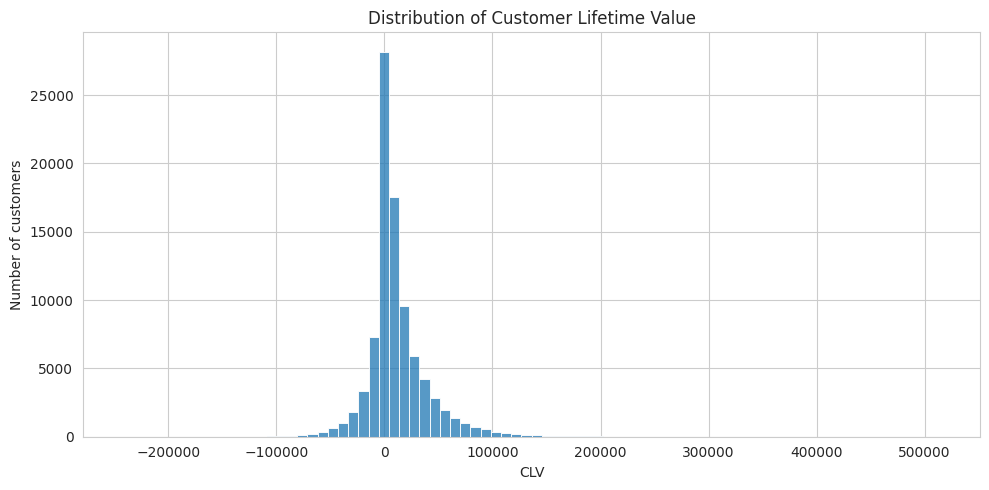

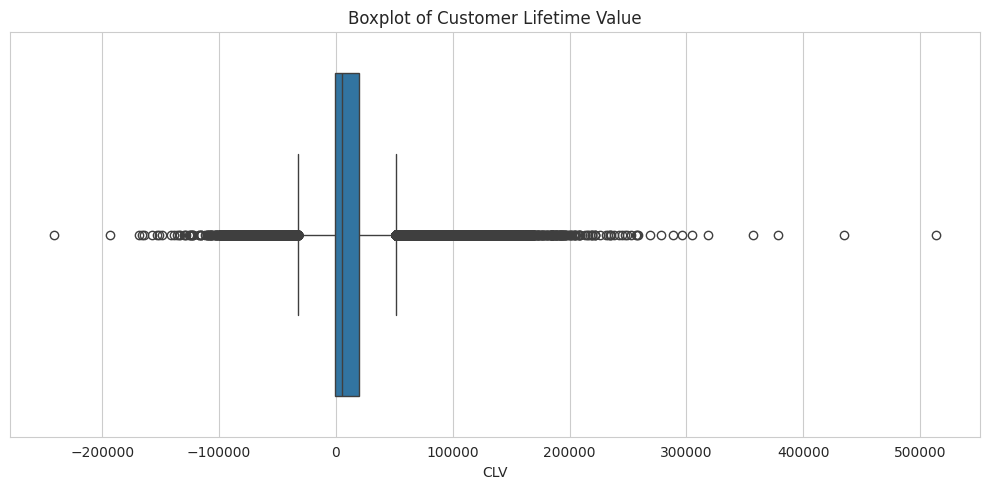

In [ ]:
# =========================================================
# 12.4 CLV SUMMARY
# =========================================================

clv_summary = pd.DataFrame({
    "metric": [
        "customers",
        "total_product_revenue_after_discount",
        "total_shipping_fee",
        "total_revenue_for_clv",
        "total_refund",
        "total_cogs",
        "total_available_cost_for_clv",
        "total_clv",
        "average_clv",
        "median_clv",
        "negative_clv_customers",
        "negative_clv_customer_rate"
    ],
    "value": [
        fact_customer["customer_id"].nunique(),
        fact_customer["net_product_revenue"].sum(),
        fact_customer["shipping_fee"].sum(),
        fact_customer["total_revenue_for_clv"].sum(),
        fact_customer["refund_amount"].sum(),
        fact_customer["cogs_amount"].sum(),
        fact_customer["available_cost_for_clv"].sum(),
        fact_customer["clv"].sum(),
        fact_customer["clv"].mean(),
        fact_customer["clv"].median(),
        (fact_customer["clv"] < 0).sum(),
        (fact_customer["clv"] < 0).mean()
    ]
})

print_section("CLV SUMMARY")
display(clv_summary)

plt.figure(figsize=(10, 5))
sns.histplot(fact_customer["clv"], bins=80)
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLV")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=fact_customer["clv"])
plt.title("Boxplot of Customer Lifetime Value")
plt.xlabel("CLV")
plt.tight_layout()
plt.show()

Tổng thể, doanh nghiệp đang tạo CLV (giá trị vòng đời khách hàng) dương, với tổng CLV khoảng 1.01 tỷ. Tuy nhiên, biên lợi nhuận thực tế sau khi trừ COGS và refund không quá cao so với tổng doanh thu. Tổng doanh thu dùng tính CLV là khoảng 15.684 tỷ, trong khi tổng CLV chỉ khoảng 1.01 tỷ, tương đương mức đóng góp ròng khoảng 6.4% doanh thu.

Điểm đáng chú ý là CLV trung bình 11,187.53 cao hơn nhiều so với CLV trung vị 4,780.54. Điều này cho thấy phân phối CLV bị lệch phải: một nhóm khách hàng nhỏ có CLV rất cao đang kéo trung bình lên. Vì vậy, nếu chỉ nhìn CLV trung bình sẽ dễ đánh giá quá lạc quan về chất lượng khách hàng.

Đặc biệt, có 25,865 khách hàng CLV âm, chiếm 28.66% tổng khách hàng. Đây là tỷ lệ khá cao. Điều này cho thấy gần 1/3 khách hàng trong dữ liệu không tạo lợi nhuận đóng góp dương sau khi trừ giá vốn và hoàn tiền. Nhóm này cần được phân tích sâu hơn theo khuyến mãi, hoàn trả, danh mục sản phẩm và vùng địa lý.


NEW CUSTOMER RATE BY YEAR 2012-2022


,year,new_customers,active_customers,new_customer_share_all_period,new_customer_rate_among_active_year
0,2012,22068,22068,0.2445,1.0000
1,2013,25099,39384,0.2781,0.6373
2,2014,13293,40376,0.1473,0.3292
3,2015,8828,40807,0.0978,0.2163
4,2016,6392,40933,0.0708,0.1562
5,2017,4789,39651,0.0531,0.1208
6,2018,3717,37922,0.0412,0.0980
7,2019,1898,27312,0.0210,0.0695
8,2020,1500,24335,0.0166,0.0616
9,2021,1340,23984,0.0148,0.0559


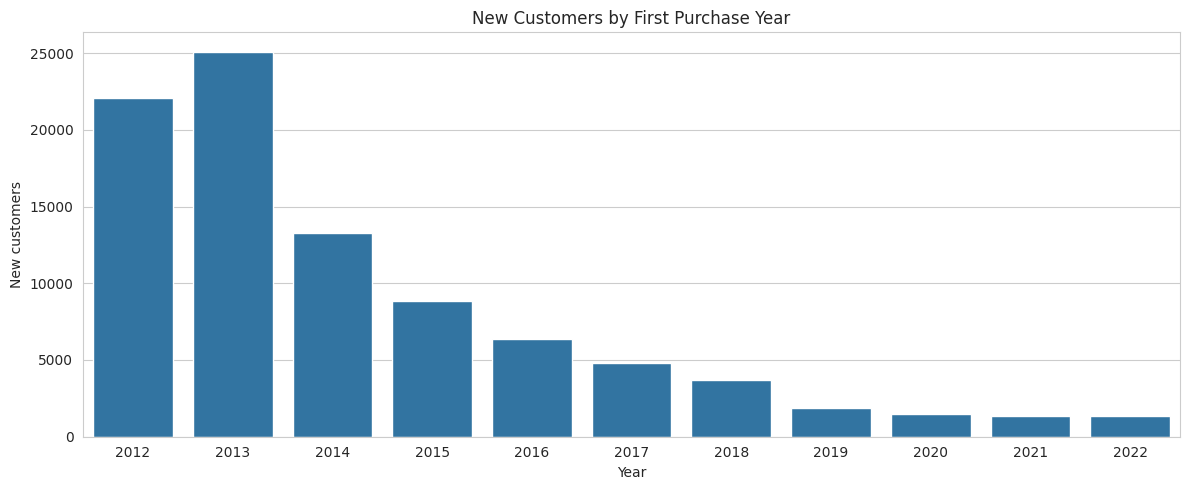

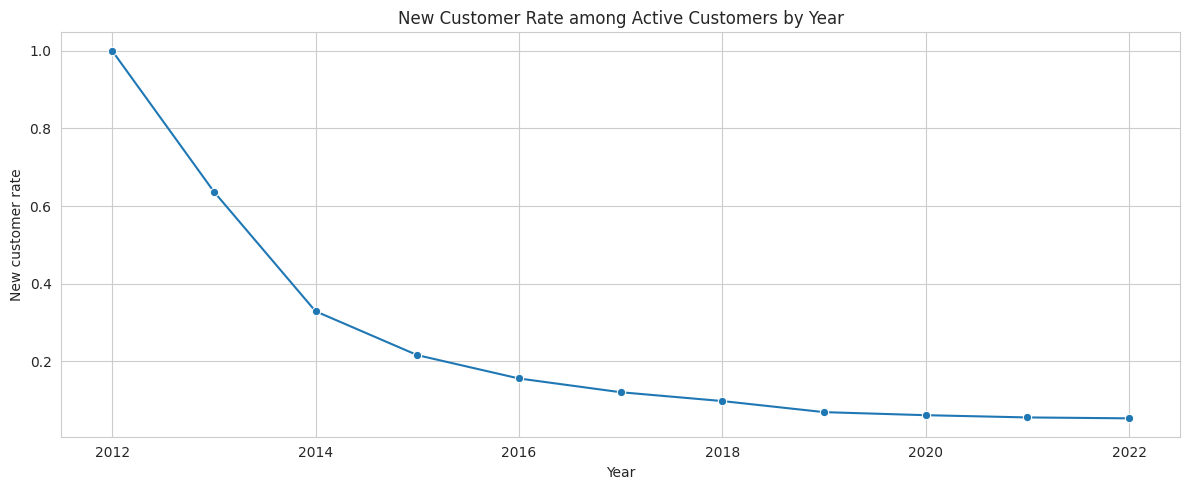

In [ ]:
# =========================================================
# 12.5 TỶ LỆ KHÁCH HÀNG MỚI THEO NĂM 2012-2022
# Logic: khách hàng mới = khách có năm mua đầu tiên = năm đang xét
# =========================================================

active_customers_by_year = (
    fact_order.groupby("order_year", as_index=False)
    .agg(active_customers=("customer_id", "nunique"))
    .rename(columns={"order_year": "year"})
)

new_customers_by_year = (
    fact_customer.groupby("first_order_year", as_index=False)
    .agg(new_customers=("customer_id", "nunique"))
    .rename(columns={"first_order_year": "year"})
)

years = pd.DataFrame({"year": list(range(2012, 2023))})

new_customer_rate_by_year = (
    years
    .merge(new_customers_by_year, on="year", how="left")
    .merge(active_customers_by_year, on="year", how="left")
)

new_customer_rate_by_year["new_customers"] = new_customer_rate_by_year["new_customers"].fillna(0).astype(int)
new_customer_rate_by_year["active_customers"] = new_customer_rate_by_year["active_customers"].fillna(0).astype(int)

total_customers_all_period = fact_customer["customer_id"].nunique()

new_customer_rate_by_year["new_customer_share_all_period"] = safe_divide(
    new_customer_rate_by_year["new_customers"],
    total_customers_all_period
)

new_customer_rate_by_year["new_customer_rate_among_active_year"] = safe_divide(
    new_customer_rate_by_year["new_customers"],
    new_customer_rate_by_year["active_customers"]
)

print_section("NEW CUSTOMER RATE BY YEAR 2012-2022")
display(new_customer_rate_by_year)

plt.figure(figsize=(12, 5))
sns.barplot(data=new_customer_rate_by_year, x="year", y="new_customers")
plt.title("New Customers by First Purchase Year")
plt.xlabel("Year")
plt.ylabel("New customers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=new_customer_rate_by_year,
    x="year",
    y="new_customer_rate_among_active_year",
    marker="o"
)
plt.title("New Customer Rate among Active Customers by Year")
plt.xlabel("Year")
plt.ylabel("New customer rate")
plt.tight_layout()
plt.show()

Năm 2012 có tỷ lệ khách hàng mới 100% vì đây là năm đầu tiên trong dữ liệu, nên toàn bộ khách active trong năm đều được xem là khách mới. Từ 2013 trở đi, tỷ lệ khách mới giảm đều.

Điều này có thể phản ánh hai khả năng:

Doanh nghiệp ngày càng phụ thuộc vào khách hàng cũ hơn là acquisition mới.

Hoạt động thu hút khách hàng mới đang suy giảm theo thời gian.

Đến năm 2022, chỉ 5.35% khách active là khách mới, cho thấy nền khách hàng chủ yếu đến từ nhóm cũ. Đây vừa là tín hiệu tốt về khả năng duy trì khách hàng, vừa là cảnh báo về tốc độ mở rộng tệp khách hàng mới.


CHURN SUMMARY 1Y / 2Y / 3Y


,metric,value
0,analysis_date,2023-01-01 00:00:00
1,customers,90246
2,avg_recency_days,"1,255.4122"
3,median_recency_days,992.0000
4,churn_1y_rate,0.7263
5,churn_2y_rate,0.5790
6,churn_3y_rate,0.4770
7,active_within_1y_rate,0.2737
8,inactive_1_2y_rate,0.1473
9,inactive_2_3y_rate,0.1020



CHURN STATUS SUMMARY


,churn_status,customers,avg_clv,total_clv,avg_orders,avg_recency_days,promo_usage_rate,return_order_rate
0,Active within 1 year,24696,"21,813.3532","538,702,571.1493",13.7560,173.5018,0.3816,0.0558
1,Inactive 1-2 years,13297,"13,327.2551","177,212,511.2532",9.1559,545.8864,0.3977,0.0550
2,Inactive 2-3 years,9205,"11,594.3820","106,726,286.1508",6.6857,911.5083,0.3817,0.0546
3,Lost over 3 years,43048,"4,343.7135","186,988,180.8588",2.8791,"2,168.7894",0.3791,0.0571


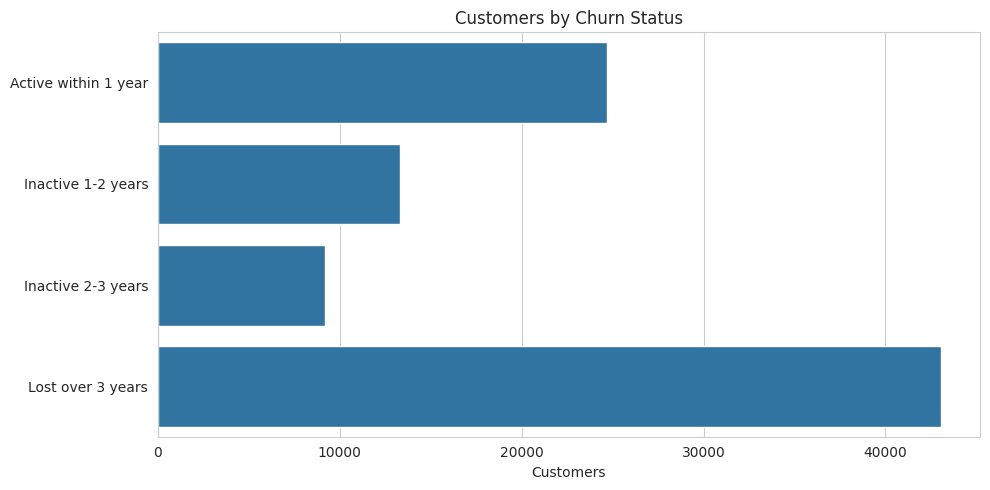


MONTHLY CHURN SNAPSHOT


,month,threshold_days,eligible_customers,churned_customers,active_customers,churn_rate,churn_definition
363,2021-10,1095,83921,34291,49630,0.4086,3Y
364,2021-11,1095,84028,34687,49341,0.4128,3Y
365,2021-12,1095,84190,35233,48957,0.4185,3Y
366,2022-01,1095,84289,35578,48711,0.4221,3Y
367,2022-02,1095,84410,36010,48400,0.4266,3Y
368,2022-03,1095,84621,36740,47881,0.4342,3Y
369,2022-04,1095,84845,37535,47310,0.4424,3Y
370,2022-05,1095,85056,38424,46632,0.4517,3Y
371,2022-06,1095,85270,39348,45922,0.4615,3Y
372,2022-07,1095,85461,40157,45304,0.4699,3Y


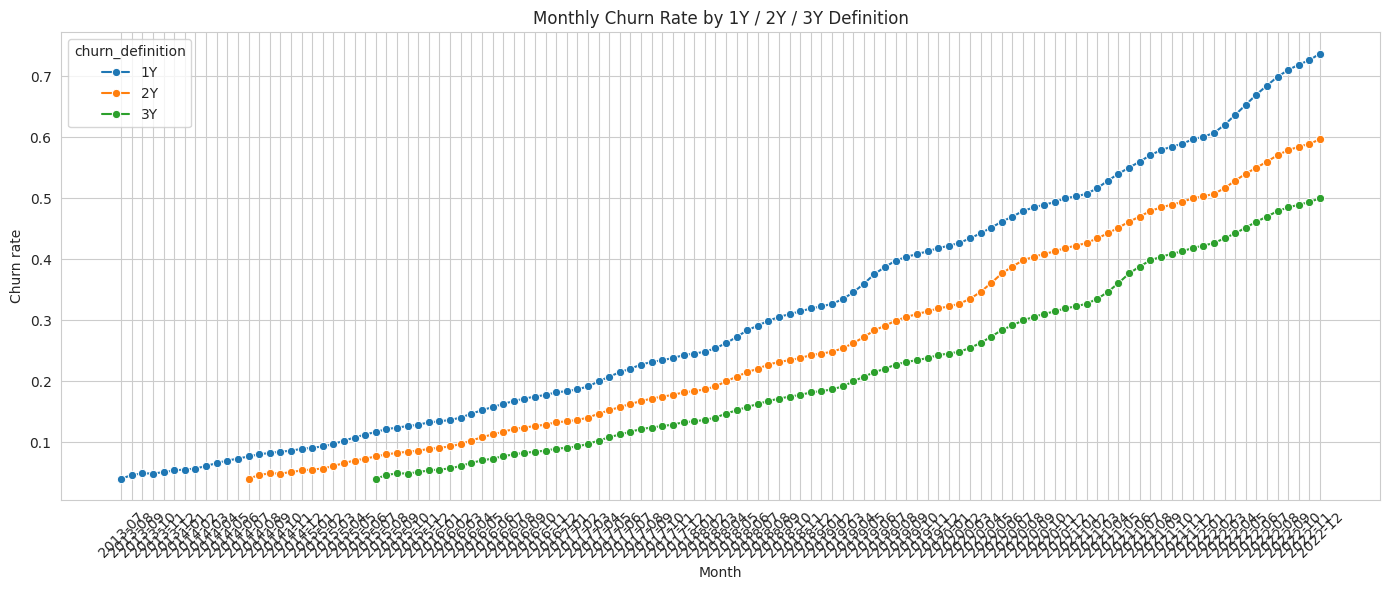

In [ ]:
# =========================================================
# 12.6 CHURN RATE 1Y / 2Y / 3Y
# Logic: khách hàng churn nếu không mua lại quá X ngày tính đến analysis_date
# =========================================================

churn_summary = pd.DataFrame({
    "metric": [
        "analysis_date",
        "customers",
        "avg_recency_days",
        "median_recency_days",
        "churn_1y_rate",
        "churn_2y_rate",
        "churn_3y_rate",
        "active_within_1y_rate",
        "inactive_1_2y_rate",
        "inactive_2_3y_rate",
        "lost_over_3y_rate"
    ],
    "value": [
        analysis_date,
        fact_customer["customer_id"].nunique(),
        fact_customer["recency_days"].mean(),
        fact_customer["recency_days"].median(),
        fact_customer["is_churn_1y"].mean(),
        fact_customer["is_churn_2y"].mean(),
        fact_customer["is_churn_3y"].mean(),
        (fact_customer["churn_status"] == "Active within 1 year").mean(),
        (fact_customer["churn_status"] == "Inactive 1-2 years").mean(),
        (fact_customer["churn_status"] == "Inactive 2-3 years").mean(),
        (fact_customer["churn_status"] == "Lost over 3 years").mean()
    ]
})

print_section("CHURN SUMMARY 1Y / 2Y / 3Y")
display(churn_summary)

churn_status_summary = (
    fact_customer.groupby("churn_status", dropna=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum"),
        avg_orders=("orders", "mean"),
        avg_recency_days=("recency_days", "mean"),
        promo_usage_rate=("promo_usage_rate", "mean"),
        return_order_rate=("return_order_rate", "mean")
    )
    .reset_index()
    .sort_values("avg_recency_days")
)

print_section("CHURN STATUS SUMMARY")
display(churn_status_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=churn_status_summary, y="churn_status", x="customers")
plt.title("Customers by Churn Status")
plt.xlabel("Customers")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Monthly churn snapshot
# ---------------------------------------------------------

def monthly_churn_snapshot(fact_customer, threshold_days):
    df = fact_customer.copy()
    df["first_order_date"] = pd.to_datetime(df["first_order_date"], errors="coerce")
    df["last_order_date"] = pd.to_datetime(df["last_order_date"], errors="coerce")

    min_month = df["first_order_date"].min().to_period("M")
    max_month = df["last_order_date"].max().to_period("M")
    months = pd.period_range(min_month, max_month, freq="M")

    rows = []

    for m in months:
        month_end = m.to_timestamp("M")
        cutoff = month_end - pd.Timedelta(days=threshold_days)

        eligible = df["first_order_date"] <= cutoff
        churned = eligible & (df["last_order_date"] <= cutoff)

        eligible_customers = int(eligible.sum())
        churned_customers = int(churned.sum())

        rows.append({
            "month": str(m),
            "threshold_days": threshold_days,
            "eligible_customers": eligible_customers,
            "churned_customers": churned_customers,
            "active_customers": eligible_customers - churned_customers,
            "churn_rate": churned_customers / eligible_customers if eligible_customers > 0 else np.nan
        })

    return pd.DataFrame(rows)


monthly_churn_1y = monthly_churn_snapshot(fact_customer, 365)
monthly_churn_2y = monthly_churn_snapshot(fact_customer, 730)
monthly_churn_3y = monthly_churn_snapshot(fact_customer, 1095)

monthly_churn_all = pd.concat([
    monthly_churn_1y.assign(churn_definition="1Y"),
    monthly_churn_2y.assign(churn_definition="2Y"),
    monthly_churn_3y.assign(churn_definition="3Y")
], ignore_index=True)

print_section("MONTHLY CHURN SNAPSHOT")
display(monthly_churn_all.tail(15))

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_churn_all.dropna(subset=["churn_rate"]),
    x="month",
    y="churn_rate",
    hue="churn_definition",
    marker="o"
)
plt.title("Monthly Churn Rate by 1Y / 2Y / 3Y Definition")
plt.xlabel("Month")
plt.ylabel("Churn rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nhóm khách hàng còn hoạt động trong vòng 1 năm có giá trị vượt trội so với nhóm đã mất trên 3 năm. Điều này cho thấy chiến lược giữ chân cần can thiệp trước khi khách bước sang trạng thái inactive dài hạn, đặc biệt trong khoảng 1–2 năm sau lần mua gần nhất.

## Customer segmentation


RFM SEGMENT SUMMARY


,rfm_segment,customers,orders,total_revenue,total_clv,avg_clv,median_clv,avg_orders,avg_aov,avg_recency_days,churn_1y_rate,churn_2y_rate,churn_3y_rate,promo_usage_rate,return_order_rate,review_rate,avg_rating,customer_share,clv_share
2,Champions,16570,296584,"7,438,493,173.8900","768,570,923.0352","46,383.2784","37,802.9219",17.8989,"25,652.6683",258.6027,0.2547,0.0000,0.0000,0.3487,0.0417,0.1734,3.9372,0.1836,0.7612
1,Big Spenders,2925,9744,"384,684,613.7700","106,094,628.8321","36,271.6680","33,695.5410",3.3313,"45,083.6271","1,289.0318",0.8270,0.6738,0.5217,0.1728,0.0181,0.1746,3.9051,0.0324,0.1051
0,At Risk,10279,52881,"1,152,966,834.7600","61,012,685.4475","5,935.6635","5,491.2788",5.1446,"21,420.3337","1,930.2310",1.0000,1.0000,1.0000,0.3852,0.0587,0.1734,3.9308,0.1139,0.0604
3,Lost / Hibernating,24581,31981,"685,174,747.0000","36,252,714.9268","1,474.8267","1,335.2452",1.3010,"21,653.3302","2,527.8228",1.0000,1.0000,1.0000,0.3753,0.0581,0.1746,3.9398,0.2724,0.0359
5,Need Attention,15358,47797,"1,117,538,040.0700","20,915,113.1624","1,361.8383","2,569.2366",3.1122,"23,685.5570",780.7575,0.7757,0.5762,0.2800,0.4179,0.0597,0.1699,3.9631,0.1702,0.0207
4,Loyal Customers,16165,201411,"4,731,914,768.7900","15,175,954.8052",938.8156,429.1476,12.4597,"23,508.8619",605.0489,0.6327,0.4066,0.1461,0.4212,0.0692,0.1680,3.9327,0.1791,0.0150
6,New Customers,4368,6547,"172,906,396.8100","1,607,529.2029",368.0241,"1,366.2623",1.4989,"26,847.1145",341.5119,0.4375,0.0000,0.0000,0.4239,0.0594,0.1580,3.8611,0.0484,0.0016



CLV SEGMENT SUMMARY


,clv_segment,customers,orders,total_revenue,total_clv,avg_clv,median_clv,avg_orders,avg_aov,avg_recency_days,churn_1y_rate,churn_2y_rate,churn_3y_rate,promo_usage_rate,return_order_rate,review_rate,avg_rating,customer_share,clv_share
4,VIP,18049,283071,"7,421,458,681.6000","959,941,712.1809","53,185.3129","44,048.9523",15.6835,"29,754.8184",600.1975,0.4869,0.2853,0.1746,0.3023,0.0354,0.1748,3.9364,0.2000,0.9508
3,High,18049,122290,"2,958,770,117.0900","289,623,110.2025","16,046.4907","15,395.1516",6.7754,"28,553.2118","1,128.2000",0.7162,0.5582,0.4328,0.2815,0.0301,0.1738,3.9256,0.2000,0.2869
2,Mid,18049,67676,"1,472,163,427.1300","91,085,537.3195","5,046.5697","4,780.6915",3.7496,"23,336.3929","1,576.0187",0.8304,0.7185,0.6220,0.2692,0.0244,0.1746,3.9335,0.2000,0.0902
1,Low-Mid,18049,50420,"906,031,907.9300","-1,667,176.8953",-92.3695,228.7004,2.7935,"13,863.8023","1,835.5642",0.8788,0.7870,0.7111,0.4690,0.0451,0.1779,3.9423,0.2000,-0.0017
0,Low,18050,123488,"2,925,254,441.3400","-329,353,633.3955","-18,246.7387","-12,453.8765",6.8414,"24,742.2835","1,137.0874",0.7195,0.5459,0.4445,0.5920,0.1460,0.1561,3.9473,0.2000,-0.3262



PROMO SEGMENT SUMMARY


,promo_segment,customers,orders,total_revenue,total_clv,avg_clv,median_clv,avg_orders,avg_aov,avg_recency_days,churn_1y_rate,churn_2y_rate,churn_3y_rate,promo_usage_rate,return_order_rate,review_rate,avg_rating,customer_share,clv_share
3,Occasional Promo Buyer,25682,305955,"7,690,535,136.6900","691,417,496.3805","26,922.2606","19,975.1527",11.9132,"25,150.2252",728.4803,0.5702,0.3743,0.2526,0.2834,0.0557,0.1709,3.9314,0.2846,0.6848
1,Low / No Promo Buyer,23040,42769,"1,148,493,439.2300","194,357,557.8266","8,435.6579","4,502.6948",1.8563,"26,975.5753","1,957.3116",0.9026,0.8281,0.7503,0.0007,0.0579,0.1675,3.9465,0.2553,0.1925
2,Moderate Promo Sensitive,28089,269976,"6,301,426,381.9200","193,745,327.7573","6,897.5516","3,954.5644",9.6114,"23,195.7133",896.5383,0.6435,0.4570,0.3426,0.5098,0.0556,0.1720,3.9383,0.3112,0.1919
0,High Promo Sensitive,13435,28245,"543,223,617.2500","-69,890,832.5523","-5,202.1461","-2,069.2391",2.1023,"18,716.5201","1,809.2877",0.8958,0.7982,0.7185,0.9625,0.0555,0.1780,3.9374,0.1489,-0.0692



LIFECYCLE SEGMENT SUMMARY


,lifecycle_segment,customers,orders,total_revenue,total_clv,avg_clv,median_clv,avg_orders,avg_aov,avg_recency_days,churn_1y_rate,churn_2y_rate,churn_3y_rate,promo_usage_rate,return_order_rate,review_rate,avg_rating,customer_share,clv_share
0,Active Repeat Buyer,23440,338461,"8,383,845,747.2100","537,021,028.4363","22,910.4534","16,419.3643",14.4395,"25,252.3025",172.3299,0.0000,0.0000,0.0000,0.3825,0.0555,0.1686,3.9380,0.2597,0.5319
4,Repeat Buyer Inactive 1-2Y,12114,120563,"2,933,626,729.9800","177,128,264.0941","14,621.7817","10,527.3544",9.9524,"24,795.2359",544.9069,1.0000,0.0000,0.0000,0.3927,0.0548,0.1684,3.9526,0.1342,0.1754
5,Repeat Buyer Inactive 2-3Y,7980,60317,"1,442,363,017.1900","104,129,301.1561","13,048.7846","9,737.2571",7.5585,"24,376.0768",910.3672,1.0000,1.0000,0.0000,0.3811,0.0548,0.1749,3.9404,0.0884,0.1031
2,Lost Repeat Buyer 3Y+,24354,105246,"2,386,810,529.9300","158,472,484.8714","6,507.0413","4,632.0536",4.3215,"22,443.5031","1,882.3613",1.0000,1.0000,1.0000,0.3805,0.0562,0.1744,3.9220,0.2699,0.1570
1,Lost One-time Buyer,21102,21102,"498,825,566.4800","31,196,928.1413","1,478.3873","1,108.4068",1.0000,"23,638.7815","2,336.3839",1.0000,0.9439,0.8859,0.3819,0.0579,0.1721,3.9321,0.2338,0.0309
3,New One-time Buyer,1256,1256,"38,206,984.3000","1,681,542.7130","1,338.8079","1,301.5426",1.0000,"30,419.5735",195.3726,0.0000,0.0000,0.0000,0.3654,0.0629,0.1632,3.9488,0.0139,0.0017


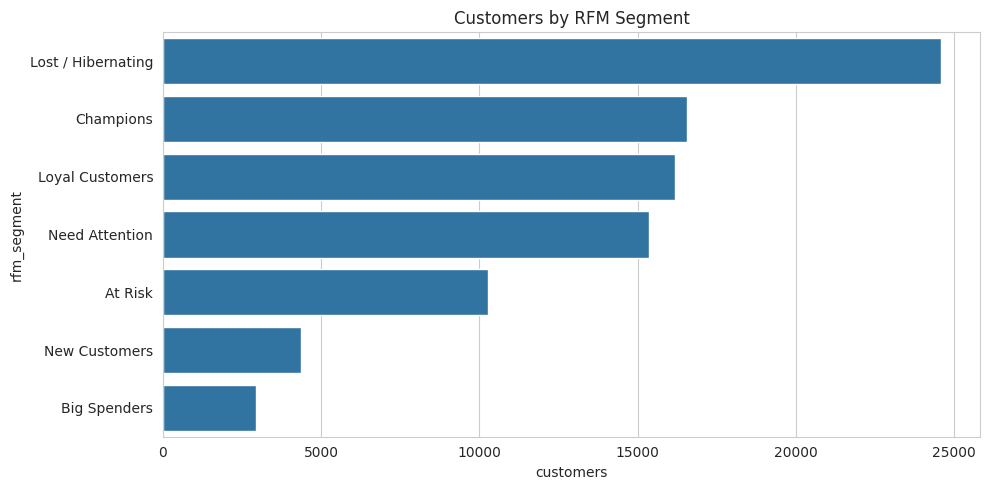

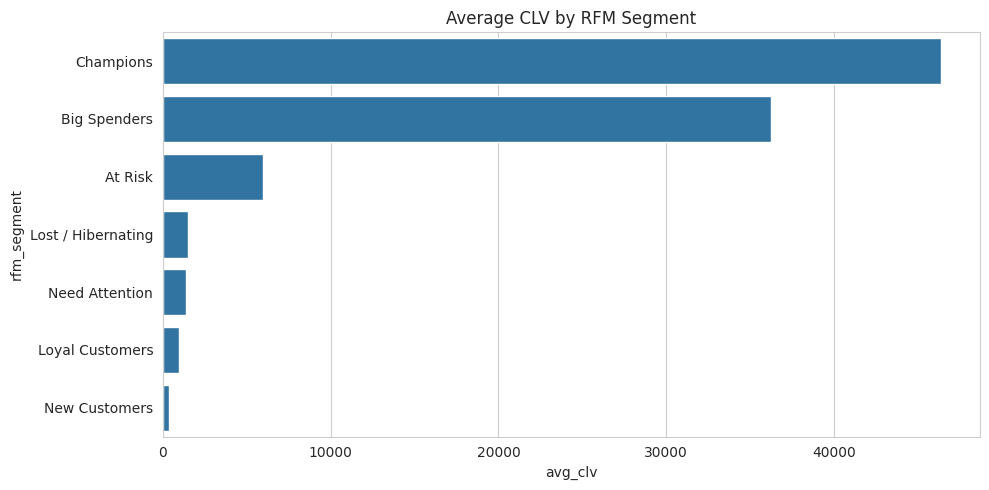

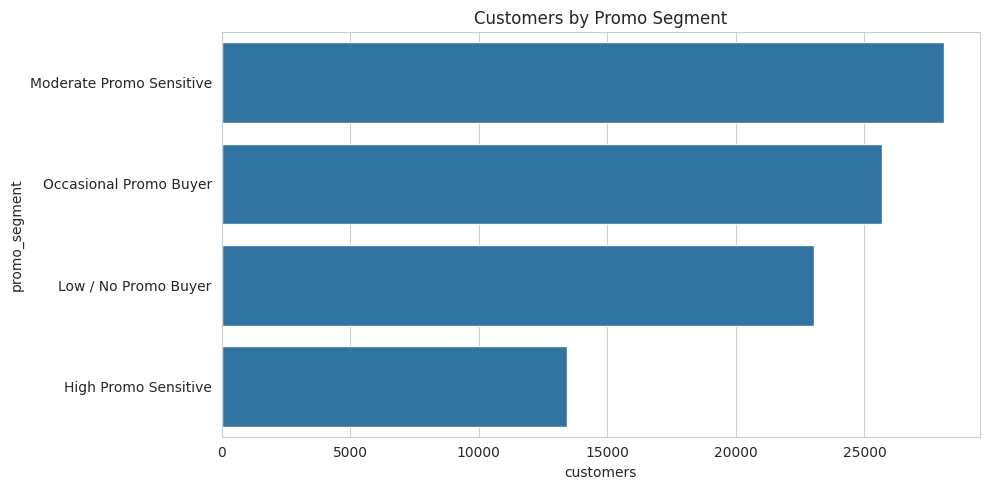

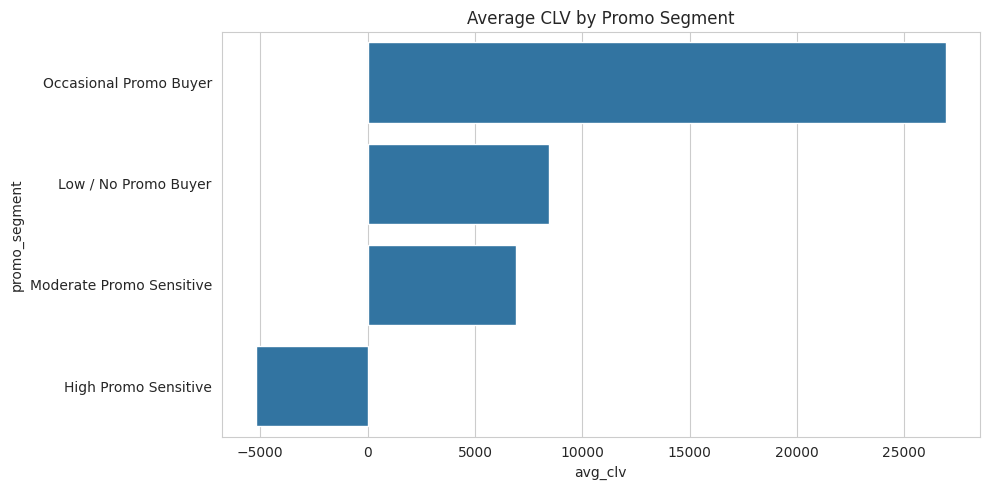

In [ ]:
# =========================================================
# 12.8 CUSTOMER SEGMENTATION
# RFM Segment | CLV Segment | Promo Segment | Lifecycle Segment
# =========================================================

# ---------------------------------------------------------
# RFM Scores
# R = Recency: mua càng gần càng tốt
# F = Frequency: số đơn càng cao càng tốt
# M = Monetary: CLV càng cao càng tốt
# ---------------------------------------------------------

fact_customer["r_score"] = score_by_rank(fact_customer["recency_days"], high_good=False)
fact_customer["f_score"] = score_by_rank(fact_customer["orders"], high_good=True)
fact_customer["m_score"] = score_by_rank(fact_customer["clv"], high_good=True)

fact_customer[["r_score", "f_score", "m_score"]] = (
    fact_customer[["r_score", "f_score", "m_score"]]
    .fillna(1)
    .astype(int)
)

fact_customer["rfm_total_score"] = (
    fact_customer["r_score"]
    + fact_customer["f_score"]
    + fact_customer["m_score"]
)

fact_customer["rfm_code"] = (
    fact_customer["r_score"].astype(str)
    + fact_customer["f_score"].astype(str)
    + fact_customer["m_score"].astype(str)
)

# ---------------------------------------------------------
# RFM segment logic
# ---------------------------------------------------------

fact_customer["rfm_segment"] = np.select(
    [
        (fact_customer["r_score"] >= 4) & (fact_customer["f_score"] >= 4) & (fact_customer["m_score"] >= 4),
        (fact_customer["r_score"] >= 3) & (fact_customer["f_score"] >= 4),
        (fact_customer["m_score"] >= 5) & (fact_customer["f_score"] <= 3),
        (fact_customer["r_score"] <= 2) & (fact_customer["f_score"] >= 3),
        (fact_customer["r_score"] <= 2) & (fact_customer["f_score"] <= 2),
        (fact_customer["r_score"] >= 4) & (fact_customer["f_score"] <= 2),
    ],
    [
        "Champions",
        "Loyal Customers",
        "Big Spenders",
        "At Risk",
        "Lost / Hibernating",
        "New Customers"
    ],
    default="Need Attention"
)

# ---------------------------------------------------------
# CLV Segment
# ---------------------------------------------------------

fact_customer["clv_segment"] = pd.qcut(
    fact_customer["clv"].rank(method="first"),
    q=5,
    labels=["Low", "Low-Mid", "Mid", "High", "VIP"]
)

# ---------------------------------------------------------
# Promo Segment
# ---------------------------------------------------------

fact_customer["promo_segment"] = np.select(
    [
        fact_customer["promo_usage_rate"] >= 0.70,
        fact_customer["promo_usage_rate"].between(0.40, 0.70, inclusive="left"),
        fact_customer["promo_usage_rate"].between(0.10, 0.40, inclusive="left"),
        fact_customer["promo_usage_rate"] < 0.10
    ],
    [
        "High Promo Sensitive",
        "Moderate Promo Sensitive",
        "Occasional Promo Buyer",
        "Low / No Promo Buyer"
    ],
    default="Unknown"
)

# ---------------------------------------------------------
# Lifecycle Segment
# ---------------------------------------------------------

fact_customer["lifecycle_segment"] = np.select(
    [
        (fact_customer["orders"] == 1) & (fact_customer["recency_days"] <= 365),
        (fact_customer["orders"] == 1) & (fact_customer["recency_days"] > 365),
        (fact_customer["orders"] >= 2) & (fact_customer["recency_days"] <= 365),
        (fact_customer["orders"] >= 2) & (fact_customer["recency_days"] > 365) & (fact_customer["recency_days"] <= 730),
        (fact_customer["orders"] >= 2) & (fact_customer["recency_days"] > 730) & (fact_customer["recency_days"] <= 1095),
        (fact_customer["orders"] >= 2) & (fact_customer["recency_days"] > 1095),
    ],
    [
        "New One-time Buyer",
        "Lost One-time Buyer",
        "Active Repeat Buyer",
        "Repeat Buyer Inactive 1-2Y",
        "Repeat Buyer Inactive 2-3Y",
        "Lost Repeat Buyer 3Y+"
    ],
    default="Other"
)


def segment_summary(df, segment_col):
    out = (
        df.groupby(segment_col, dropna=False)
        .agg(
            customers=("customer_id", "nunique"),
            orders=("orders", "sum"),
            total_revenue=("total_revenue_for_clv", "sum"),
            total_clv=("clv", "sum"),
            avg_clv=("clv", "mean"),
            median_clv=("clv", "median"),
            avg_orders=("orders", "mean"),
            avg_aov=("aov", "mean"),
            avg_recency_days=("recency_days", "mean"),
            churn_1y_rate=("is_churn_1y", "mean"),
            churn_2y_rate=("is_churn_2y", "mean"),
            churn_3y_rate=("is_churn_3y", "mean"),
            promo_usage_rate=("promo_usage_rate", "mean"),
            return_order_rate=("return_order_rate", "mean"),
            review_rate=("review_rate", "mean"),
            avg_rating=("avg_rating", "mean")
        )
        .reset_index()
    )

    out["customer_share"] = safe_divide(out["customers"], out["customers"].sum())
    out["clv_share"] = safe_divide(out["total_clv"], out["total_clv"].sum())

    return out.sort_values("avg_clv", ascending=False)


rfm_summary = segment_summary(fact_customer, "rfm_segment")
clv_segment_summary = segment_summary(fact_customer, "clv_segment")
promo_segment_summary = segment_summary(fact_customer, "promo_segment")
lifecycle_segment_summary = segment_summary(fact_customer, "lifecycle_segment")

print_section("RFM SEGMENT SUMMARY")
display(rfm_summary)

print_section("CLV SEGMENT SUMMARY")
display(clv_segment_summary)

print_section("PROMO SEGMENT SUMMARY")
display(promo_segment_summary)

print_section("LIFECYCLE SEGMENT SUMMARY")
display(lifecycle_segment_summary)

plot_top_bar(rfm_summary, "rfm_segment", "customers", "Customers by RFM Segment", n=10)
plot_top_bar(rfm_summary, "rfm_segment", "avg_clv", "Average CLV by RFM Segment", n=10)
plot_top_bar(promo_segment_summary, "promo_segment", "customers", "Customers by Promo Segment", n=10)
plot_top_bar(promo_segment_summary, "promo_segment", "avg_clv", "Average CLV by Promo Segment", n=10)

In [ ]:
# =========================================================
# 12.9 SEGMENT DEFINITIONS AND CHARACTERISTICS
# =========================================================

segment_description = pd.DataFrame({
    "segment_type": [
        "RFM", "RFM", "RFM", "RFM", "RFM", "RFM",
        "Promo", "Promo", "Promo", "Promo",
        "Lifecycle", "Lifecycle", "Lifecycle", "Lifecycle"
    ],
    "segment": [
        "Champions",
        "Loyal Customers",
        "Big Spenders",
        "At Risk",
        "Lost / Hibernating",
        "New Customers",
        "High Promo Sensitive",
        "Moderate Promo Sensitive",
        "Occasional Promo Buyer",
        "Low / No Promo Buyer",
        "New One-time Buyer",
        "Active Repeat Buyer",
        "Repeat Buyer Inactive 1-2Y",
        "Lost Repeat Buyer 3Y+"
    ],
    "logic": [
        "Recency cao, Frequency cao, CLV cao",
        "Mua tương đối gần đây và tần suất mua cao",
        "CLV rất cao nhưng tần suất không quá cao",
        "Từng mua nhiều nhưng lâu chưa quay lại",
        "Lâu chưa mua lại và giá trị thấp",
        "Mới mua gần đây nhưng tần suất còn thấp",
        "Từ 70% đơn hàng trở lên có dùng promo",
        "40%-70% đơn hàng có dùng promo",
        "10%-40% đơn hàng có dùng promo",
        "Dưới 10% đơn hàng có dùng promo",
        "Chỉ có 1 đơn và mua trong vòng 1 năm gần nhất",
        "Có từ 2 đơn trở lên và mua trong vòng 1 năm gần nhất",
        "Có từ 2 đơn trở lên nhưng 1-2 năm chưa mua lại",
        "Có từ 2 đơn trở lên nhưng hơn 3 năm chưa mua lại"
    ],
    "business_interpretation": [
        "Nhóm khách hàng tốt nhất, ưu tiên loyalty, cá nhân hóa và early access.",
        "Nhóm có thói quen mua lại, phù hợp cho cross-sell và bundle.",
        "Nhóm chi tiêu lớn, phù hợp upsell sản phẩm cao cấp.",
        "Nhóm có nguy cơ rời bỏ, nên chạy win-back có chọn lọc.",
        "Nhóm ưu tiên thấp, chỉ nên remarketing chi phí thấp.",
        "Nhóm cần onboarding và kích hoạt mua lần hai.",
        "Nhạy cảm với giảm giá, cần kiểm soát discount để tránh CLV âm.",
        "Có phản ứng với promo, nên cá nhân hóa ưu đãi.",
        "Promo hỗ trợ quyết định mua nhưng không phải động lực duy nhất.",
        "Ít phụ thuộc promo, có thể tạo biên lợi nhuận tốt hơn.",
        "Cần kích hoạt mua lần hai để tăng retention.",
        "Nhóm đang hoạt động tốt, nên giữ chân và tăng basket size.",
        "Nên win-back nếu CLV cao.",
        "Đã mất lâu, nên hạn chế ngân sách tái kích hoạt."
    ]
})

print_section("SEGMENT DEFINITIONS AND CHARACTERISTICS")
display(segment_description)


SEGMENT DEFINITIONS AND CHARACTERISTICS


,segment_type,segment,logic,business_interpretation
0,RFM,Champions,"Recency cao, Frequency cao, CLV cao","Nhóm khách hàng tốt nhất, ưu tiên loyalty, cá ..."
1,RFM,Loyal Customers,Mua tương đối gần đây và tần suất mua cao,"Nhóm có thói quen mua lại, phù hợp cho cross-s..."
2,RFM,Big Spenders,CLV rất cao nhưng tần suất không quá cao,"Nhóm chi tiêu lớn, phù hợp upsell sản phẩm cao..."
3,RFM,At Risk,Từng mua nhiều nhưng lâu chưa quay lại,"Nhóm có nguy cơ rời bỏ, nên chạy win-back có c..."
4,RFM,Lost / Hibernating,Lâu chưa mua lại và giá trị thấp,"Nhóm ưu tiên thấp, chỉ nên remarketing chi phí..."
5,RFM,New Customers,Mới mua gần đây nhưng tần suất còn thấp,Nhóm cần onboarding và kích hoạt mua lần hai.
6,Promo,High Promo Sensitive,Từ 70% đơn hàng trở lên có dùng promo,"Nhạy cảm với giảm giá, cần kiểm soát discount ..."
7,Promo,Moderate Promo Sensitive,40%-70% đơn hàng có dùng promo,"Có phản ứng với promo, nên cá nhân hóa ưu đãi."
8,Promo,Occasional Promo Buyer,10%-40% đơn hàng có dùng promo,Promo hỗ trợ quyết định mua nhưng không phải đ...
9,Promo,Low / No Promo Buyer,Dưới 10% đơn hàng có dùng promo,"Ít phụ thuộc promo, có thể tạo biên lợi nhuận ..."



PEARSON CORRELATION: PROMO USAGE RATE VS CLV


,promo_usage_rate,discount_rate,clv,orders,aov,return_order_rate,refund_rate
promo_usage_rate,1.0000,0.8392,-0.2170,0.0024,-0.1845,-0.0047,0.0095
discount_rate,0.8392,1.0000,-0.2498,-0.0328,-0.2019,-0.0045,0.0136
clv,-0.2170,-0.2498,1.0000,0.4852,0.1473,-0.1787,-0.2444
orders,0.0024,-0.0328,0.4852,1.0000,0.0109,-0.0025,-0.0106
aov,-0.1845,-0.2019,0.1473,0.0109,1.0000,-0.0052,-0.0236
return_order_rate,-0.0047,-0.0045,-0.1787,-0.0025,-0.0052,1.0000,0.8566
refund_rate,0.0095,0.0136,-0.2444,-0.0106,-0.0236,0.8566,1.0000



SPEARMAN CORRELATION: PROMO USAGE RATE VS CLV


,promo_usage_rate,discount_rate,clv,orders,aov,return_order_rate,refund_rate
promo_usage_rate,1.0000,0.8741,-0.3325,0.1145,-0.1459,0.0382,0.0406
discount_rate,0.8741,1.0000,-0.3114,0.1994,-0.1495,0.0733,0.0787
clv,-0.3325,-0.3114,1.0000,0.3848,0.2915,-0.0939,-0.1069
orders,0.1145,0.1994,0.3848,1.0000,0.1754,0.4084,0.4272
aov,-0.1459,-0.1495,0.2915,0.1754,1.0000,0.0672,0.0662
return_order_rate,0.0382,0.0733,-0.0939,0.4084,0.0672,1.0000,0.9898
refund_rate,0.0406,0.0787,-0.1069,0.4272,0.0662,0.9898,1.0000


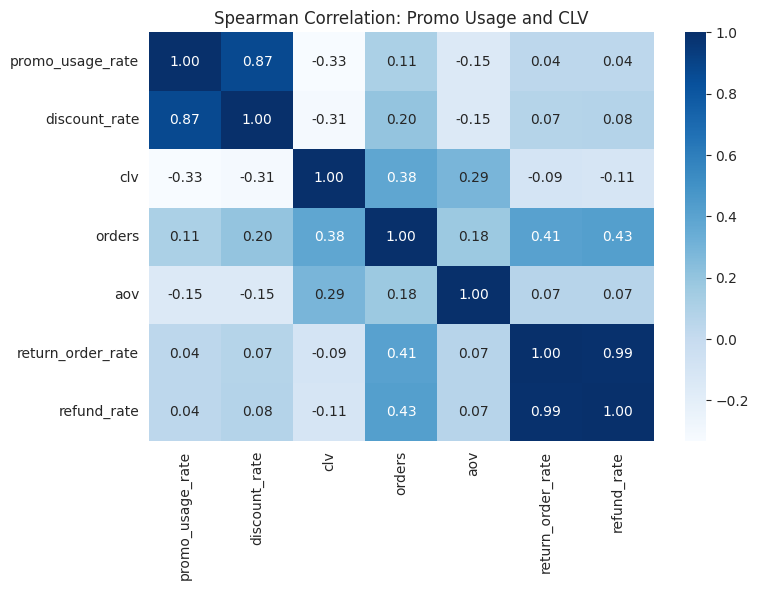

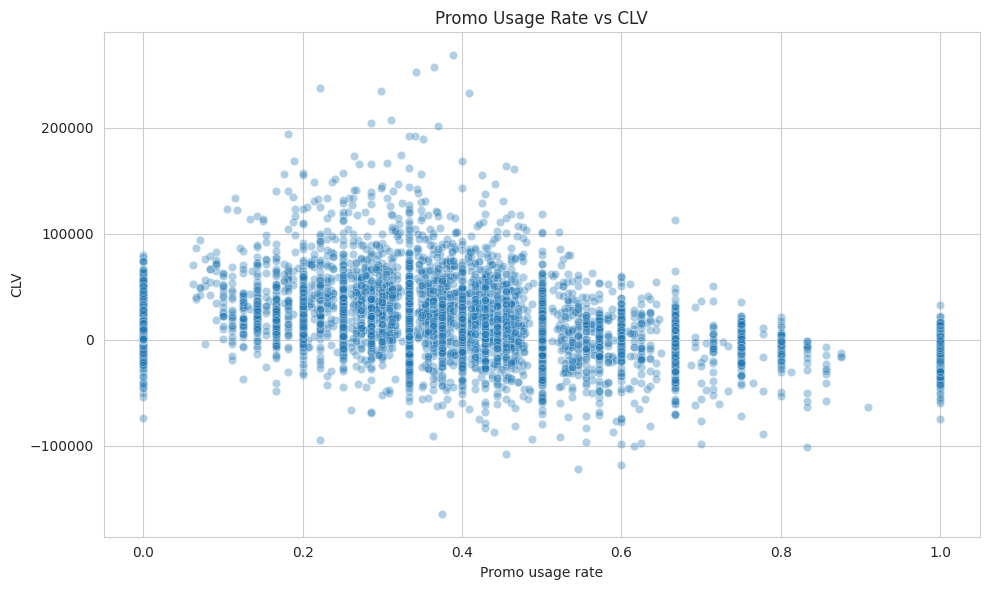

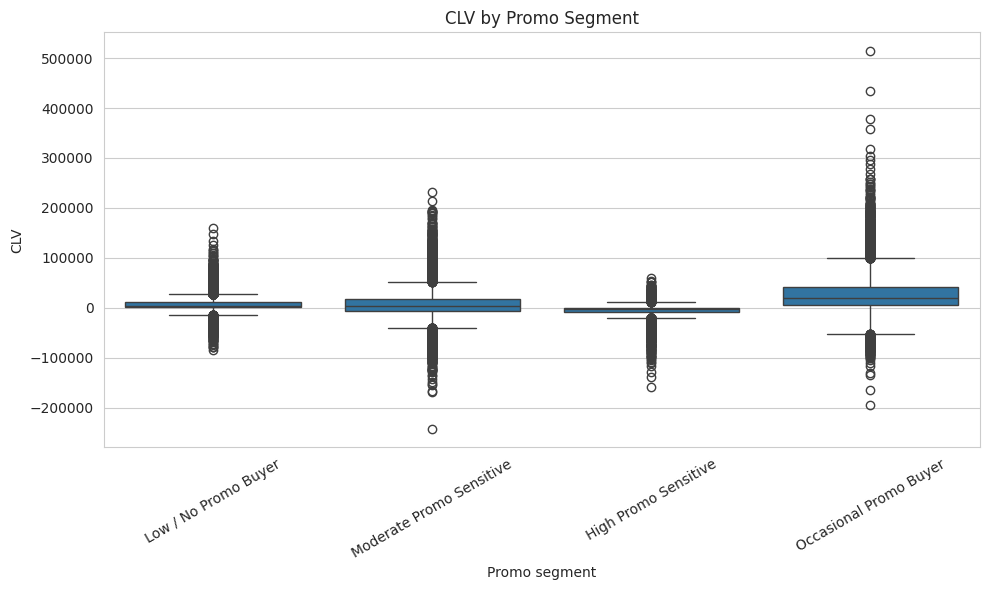


PROMO USAGE BIN SUMMARY


,promo_usage_bin,customers,avg_clv,median_clv,total_clv,avg_orders,avg_aov,avg_discount_rate,churn_1y_rate,churn_2y_rate,churn_3y_rate,return_order_rate,refund_rate,customer_share,clv_share
0,0%,22835,"8,039.3519","4,420.7252","183,578,600.3680",1.7583,"26,978.4998",0.0000,0.9067,0.8330,0.7560,0.0580,0.0349,0.2530,0.1818
1,0-25%,9996,"27,442.9170","21,719.4110","274,319,398.6116",9.2126,"25,821.7350",0.0243,0.6233,0.4216,0.2815,0.0556,0.0331,0.1108,0.2717
2,25-50%,35815,"17,375.5721","10,366.4308","622,306,113.7330",11.4782,"24,128.9104",0.0496,0.5954,0.4113,0.3012,0.0556,0.0333,0.3969,0.6164
3,50-75%,9609,"-1,139.6246",-288.0204,"-10,950,652.7147",8.7432,"21,901.9070",0.0789,0.6545,0.4478,0.3212,0.0550,0.0346,0.1065,-0.0108
4,75-100%,11991,"-4,972.3885","-1,983.0694","-59,623,910.5858",1.6346,"18,482.6721",0.1386,0.9173,0.8326,0.7586,0.0560,0.0385,0.1329,-0.0591


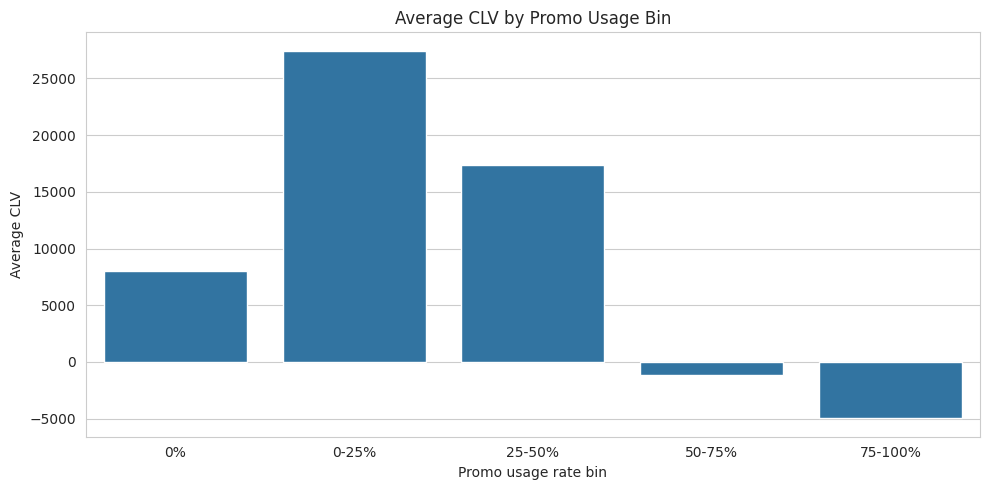

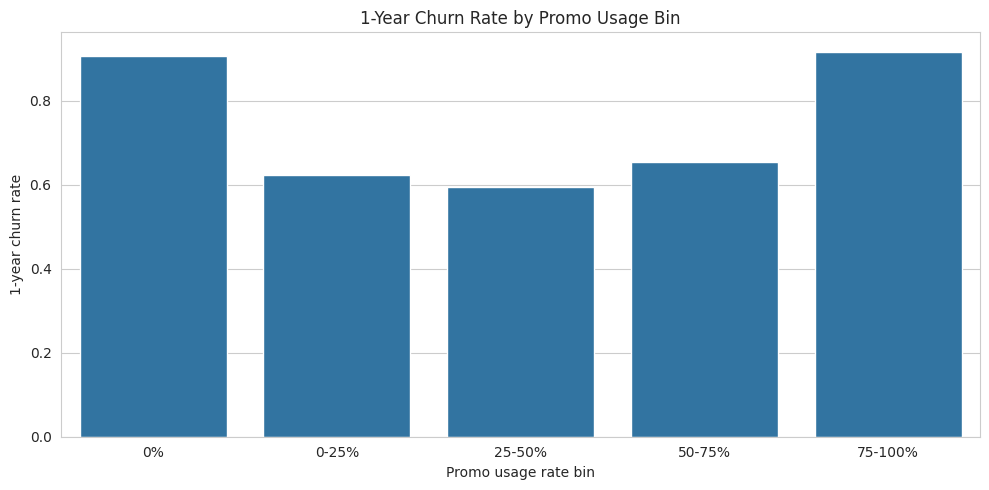

In [ ]:
# =========================================================
# 12.10 PROMO USAGE RATE VS CLV
# =========================================================

promo_clv_cols = [
    "promo_usage_rate", "discount_rate", "clv", "orders",
    "aov", "return_order_rate", "refund_rate"
]

promo_clv_cols = [c for c in promo_clv_cols if c in fact_customer.columns]

promo_clv_corr_pearson = fact_customer[promo_clv_cols].corr(method="pearson", numeric_only=True)
promo_clv_corr_spearman = fact_customer[promo_clv_cols].corr(method="spearman", numeric_only=True)

print_section("PEARSON CORRELATION: PROMO USAGE RATE VS CLV")
display(promo_clv_corr_pearson)

print_section("SPEARMAN CORRELATION: PROMO USAGE RATE VS CLV")
display(promo_clv_corr_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(promo_clv_corr_spearman, annot=True, fmt=".2f", cmap="Blues")
plt.title("Spearman Correlation: Promo Usage and CLV")
plt.tight_layout()
plt.show()

sample_size = min(10000, len(fact_customer))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=fact_customer.sample(sample_size, random_state=42),
    x="promo_usage_rate",
    y="clv",
    alpha=0.35
)
plt.title("Promo Usage Rate vs CLV")
plt.xlabel("Promo usage rate")
plt.ylabel("CLV")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=fact_customer, x="promo_segment", y="clv")
plt.title("CLV by Promo Segment")
plt.xlabel("Promo segment")
plt.ylabel("CLV")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Promo bin analysis
# ---------------------------------------------------------

fact_customer["promo_usage_bin"] = pd.cut(
    fact_customer["promo_usage_rate"],
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.00],
    labels=["0%", "0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

promo_bin_summary = (
    fact_customer.groupby("promo_usage_bin", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        total_clv=("clv", "sum"),
        avg_orders=("orders", "mean"),
        avg_aov=("aov", "mean"),
        avg_discount_rate=("discount_rate", "mean"),
        churn_1y_rate=("is_churn_1y", "mean"),
        churn_2y_rate=("is_churn_2y", "mean"),
        churn_3y_rate=("is_churn_3y", "mean"),
        return_order_rate=("return_order_rate", "mean"),
        refund_rate=("refund_rate", "mean")
    )
    .reset_index()
)

promo_bin_summary["customer_share"] = safe_divide(
    promo_bin_summary["customers"],
    promo_bin_summary["customers"].sum()
)

promo_bin_summary["clv_share"] = safe_divide(
    promo_bin_summary["total_clv"],
    promo_bin_summary["total_clv"].sum()
)

print_section("PROMO USAGE BIN SUMMARY")
display(promo_bin_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=promo_bin_summary, x="promo_usage_bin", y="avg_clv")
plt.title("Average CLV by Promo Usage Bin")
plt.xlabel("Promo usage rate bin")
plt.ylabel("Average CLV")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=promo_bin_summary, x="promo_usage_bin", y="churn_1y_rate")
plt.title("1-Year Churn Rate by Promo Usage Bin")
plt.xlabel("Promo usage rate bin")
plt.ylabel("1-year churn rate")
plt.tight_layout()
plt.show()


CLV OVERALL SUMMARY


,metric,value
0,customers,"90,246.0000"
1,total_revenue_for_clv,"15,683,678,575.0900"
2,total_clv,"1,009,629,549.4121"
3,average_clv,"11,187.5269"
4,median_clv,"4,780.5442"
5,min_clv,"-241,252.0326"
6,max_clv,"513,610.6559"
7,negative_clv_customers,"25,865.0000"
8,negative_clv_customer_rate,0.2866
9,positive_clv_customers,"64,381.0000"



CLV PERCENTILES


,percentile,clv_value
0,0.0000,"-241,252.0326"
1,0.0100,"-52,455.8403"
2,0.0500,"-23,613.3289"
3,0.1000,"-12,453.8765"
4,0.2000,"-3,261.9996"
5,0.2500,"-1,106.2817"
6,0.5000,"4,780.5442"
7,0.7500,"19,809.8064"
8,0.8000,"25,511.2882"
9,0.9000,"44,048.8536"


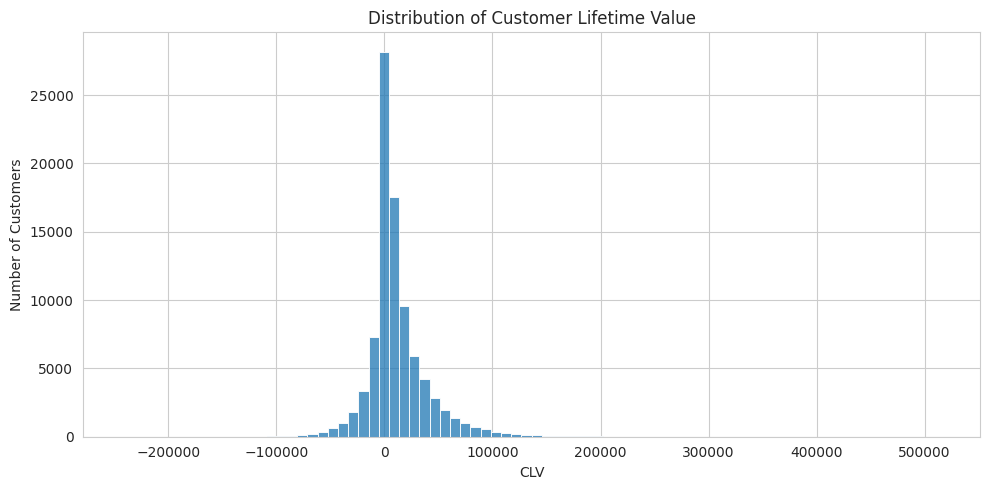

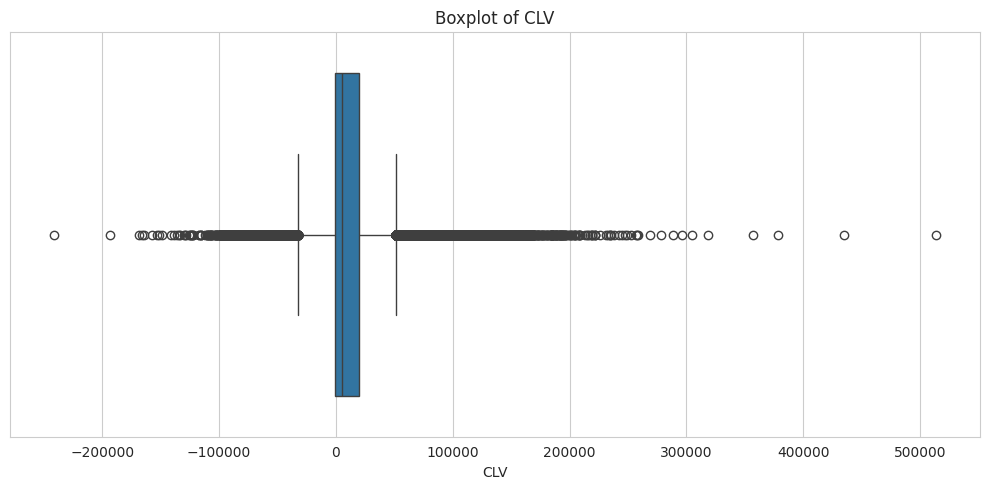

In [ ]:
# =========================================================
# 13.1 CLV SUMMARY AND PERCENTILES
# =========================================================

clv_percentiles = fact_customer["clv"].quantile(
    [0, 0.01, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 1]
).reset_index()

clv_percentiles.columns = ["percentile", "clv_value"]

clv_overall_summary = pd.DataFrame({
    "metric": [
        "customers",
        "total_revenue_for_clv",
        "total_clv",
        "average_clv",
        "median_clv",
        "min_clv",
        "max_clv",
        "negative_clv_customers",
        "negative_clv_customer_rate",
        "positive_clv_customers",
        "positive_clv_customer_rate"
    ],
    "value": [
        fact_customer["customer_id"].nunique(),
        fact_customer["total_revenue_for_clv"].sum(),
        fact_customer["clv"].sum(),
        fact_customer["clv"].mean(),
        fact_customer["clv"].median(),
        fact_customer["clv"].min(),
        fact_customer["clv"].max(),
        (fact_customer["clv"] < 0).sum(),
        (fact_customer["clv"] < 0).mean(),
        (fact_customer["clv"] > 0).sum(),
        (fact_customer["clv"] > 0).mean()
    ]
})

print_section("CLV OVERALL SUMMARY")
display(clv_overall_summary)

print_section("CLV PERCENTILES")
display(clv_percentiles)


plt.figure(figsize=(10, 5))
sns.histplot(fact_customer["clv"], bins=80)
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(x=fact_customer["clv"])
plt.title("Boxplot of CLV")
plt.xlabel("CLV")
plt.tight_layout()
plt.show()


CLV PERCENTILE SEGMENTS CONTRIBUTION


,clv_percentile_segment,customers,total_orders,total_revenue,total_clv,avg_clv,median_clv,avg_revenue_per_customer,avg_orders_per_customer,avg_aov,avg_recency_days,churn_1y_rate,promo_usage_rate,return_order_rate,customer_share,revenue_share,clv_share
4,Top 20% / VIP,18050,283077,"7,421,609,206.1600","959,967,223.4691","53,183.7797","44,048.8536","411,169.4851",15.6829,"29,754.5599",600.1784,0.4869,0.3023,0.0354,0.2000,0.4732,0.9508
3,High 20%,18049,122289,"2,958,662,985.4300","289,606,764.3941","16,045.5850","15,394.7363","163,923.9285",6.7754,"28,552.3027","1,128.2572",0.7163,0.2815,0.0301,0.2000,0.1886,0.2868
2,Middle 20%,18049,67672,"1,472,128,146.4800","91,078,368.5333","5,046.1726","4,780.3969","81,562.8648",3.7493,"23,336.3615","1,576.0609",0.8304,0.2692,0.0244,0.2000,0.0939,0.0902
1,Low-Mid 20%,18049,50420,"906,030,612.9900","-1,672,435.5885",-92.6608,228.6545,"50,198.3829",2.7935,"13,863.7305","1,835.5316",0.8788,0.4691,0.0451,0.2000,0.0578,-0.0017
0,Bottom 20%,18049,123487,"2,925,247,624.0300","-329,350,371.3959","-18,247.5689","-12,454.3312","162,072.5594",6.8418,"24,743.2766","1,137.0693",0.7195,0.5919,0.1460,0.2000,0.1865,-0.3262


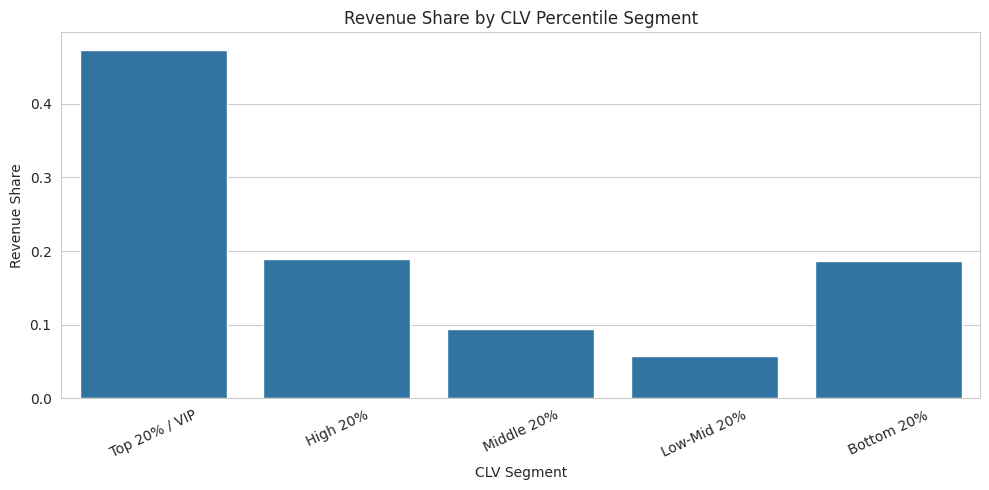

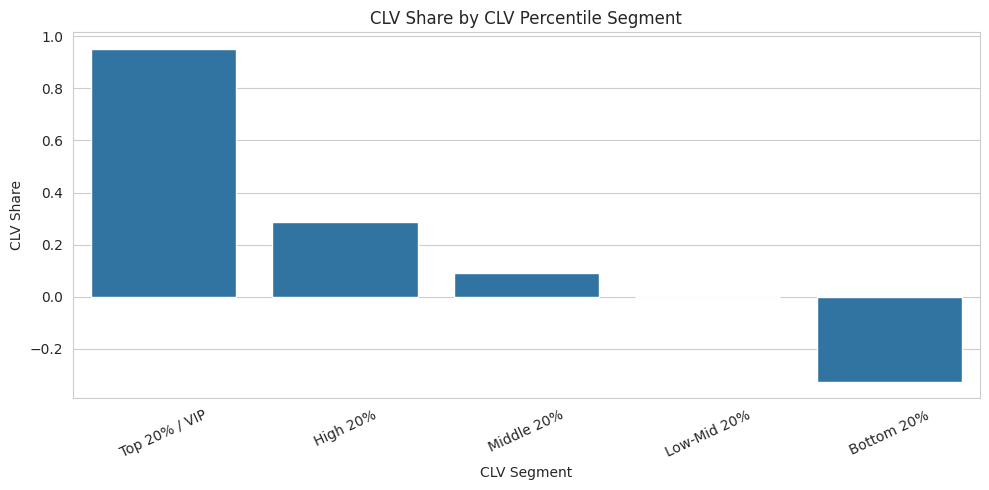

In [ ]:
# =========================================================
# 13.2 CLV PERCENTILE SEGMENTS AND REVENUE CONTRIBUTION
# =========================================================

customer_clv = fact_customer.copy()

# Xếp hạng khách hàng theo CLV từ thấp đến cao để chia nhóm phân vị
customer_clv["clv_percentile_rank"] = customer_clv["clv"].rank(pct=True, method="first")

customer_clv["clv_percentile_segment"] = pd.cut(
    customer_clv["clv_percentile_rank"],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.000001],
    labels=[
        "Bottom 20%",
        "Low-Mid 20%",
        "Middle 20%",
        "High 20%",
        "Top 20% / VIP"
    ],
    include_lowest=True
)

clv_segment_contribution = (
    customer_clv.groupby("clv_percentile_segment", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_orders=("orders", "sum"),
        total_revenue=("total_revenue_for_clv", "sum"),
        total_clv=("clv", "sum"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        avg_revenue_per_customer=("total_revenue_for_clv", "mean"),
        avg_orders_per_customer=("orders", "mean"),
        avg_aov=("aov", "mean") if "aov" in customer_clv.columns else ("total_revenue_for_clv", "mean"),
        avg_recency_days=("recency_days", "mean") if "recency_days" in customer_clv.columns else ("orders", "mean"),
        churn_1y_rate=("is_churn_1y", "mean") if "is_churn_1y" in customer_clv.columns else ("orders", "mean"),
        promo_usage_rate=("promo_usage_rate", "mean") if "promo_usage_rate" in customer_clv.columns else ("orders", "mean"),
        return_order_rate=("return_order_rate", "mean") if "return_order_rate" in customer_clv.columns else ("orders", "mean")
    )
    .reset_index()
)

clv_segment_contribution["customer_share"] = safe_divide(
    clv_segment_contribution["customers"],
    clv_segment_contribution["customers"].sum()
)

clv_segment_contribution["revenue_share"] = safe_divide(
    clv_segment_contribution["total_revenue"],
    clv_segment_contribution["total_revenue"].sum()
)

clv_segment_contribution["clv_share"] = safe_divide(
    clv_segment_contribution["total_clv"],
    clv_segment_contribution["total_clv"].sum()
)

# Sắp xếp từ Top 20 xuống Bottom 20
segment_order = [
    "Top 20% / VIP",
    "High 20%",
    "Middle 20%",
    "Low-Mid 20%",
    "Bottom 20%"
]

clv_segment_contribution["clv_percentile_segment"] = pd.Categorical(
    clv_segment_contribution["clv_percentile_segment"],
    categories=segment_order,
    ordered=True
)

clv_segment_contribution = clv_segment_contribution.sort_values("clv_percentile_segment")

print_section("CLV PERCENTILE SEGMENTS CONTRIBUTION")
display(clv_segment_contribution)


plt.figure(figsize=(10, 5))
sns.barplot(
    data=clv_segment_contribution,
    x="clv_percentile_segment",
    y="revenue_share"
)
plt.title("Revenue Share by CLV Percentile Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Revenue Share")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(
    data=clv_segment_contribution,
    x="clv_percentile_segment",
    y="clv_share"
)
plt.title("CLV Share by CLV Percentile Segment")
plt.xlabel("CLV Segment")
plt.ylabel("CLV Share")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Đây là bảng quan trọng nhất để chứng minh nguyên tắc không phải khách hàng tạo doanh thu cao đều tạo giá trị cao.

Nhóm Top 20% / VIP chỉ chiếm 20% số khách hàng nhưng tạo ra 47.32% tổng doanh thu và đến 95.08% tổng CLV. Điều này cho thấy lợi nhuận của doanh nghiệp phụ thuộc rất lớn vào nhóm khách hàng giá trị cao. Đây là nhóm nên được ưu tiên trong loyalty program, cá nhân hóa ưu đãi, early access và chăm sóc riêng.

Nhóm High 20% cũng đóng góp tích cực, với 18.86% doanh thu và 28.68% CLV. Nếu cộng hai nhóm cao nhất, top 40% khách hàng đang tạo ra khoảng 66.18% doanh thu và hơn 100% tổng CLV. Lý do tỷ trọng CLV có thể vượt 100% là vì các nhóm dưới có CLV âm, kéo tổng CLV toàn bộ xuống.

Điểm đáng lo nhất là Bottom 20%. Nhóm này vẫn tạo ra 18.65% doanh thu, gần ngang với nhóm High 20%, nhưng lại tạo CLV âm -329.35 triệu, tương đương -32.62% tổng CLV. Điều này nghĩa là doanh nghiệp có thể đang “bán càng nhiều càng lỗ” ở nhóm này. Nguyên nhân có thể đến từ giá vốn cao, hoàn trả cao, discount sâu, phí vận hành không được phản ánh đầy đủ, hoặc cơ cấu sản phẩm kém lợi nhuận.

Nhóm Low-Mid 20% gần như hòa vốn nhưng vẫn âm nhẹ. Đây là nhóm có thể cải thiện bằng cách giảm khuyến mãi sâu, tăng basket size hoặc đề xuất sản phẩm có margin cao hơn.

Doanh nghiệp nên tập trung giữ chân top 10%–20% khách hàng theo CLV, vì đây là nhóm tạo phần lớn giá trị ròng. Đồng thời, cần kiểm soát nhóm khách hàng có doanh thu cao nhưng CLV âm để tránh tình trạng tăng doanh thu nhưng giảm lợi nhuận.


REPURCHASE CYCLE SUMMARY


,metric,value
0,repeat_orders,"556,699.0000"
1,repeat_customers,"67,888.0000"
2,avg_days_between_orders,285.5925
3,median_days_between_orders,144.0000
4,p25_days_between_orders,46.0000
5,p75_days_between_orders,357.0000
6,p90_days_between_orders,733.0000
7,min_days_between_orders,0.0000
8,max_days_between_orders,"3,785.0000"


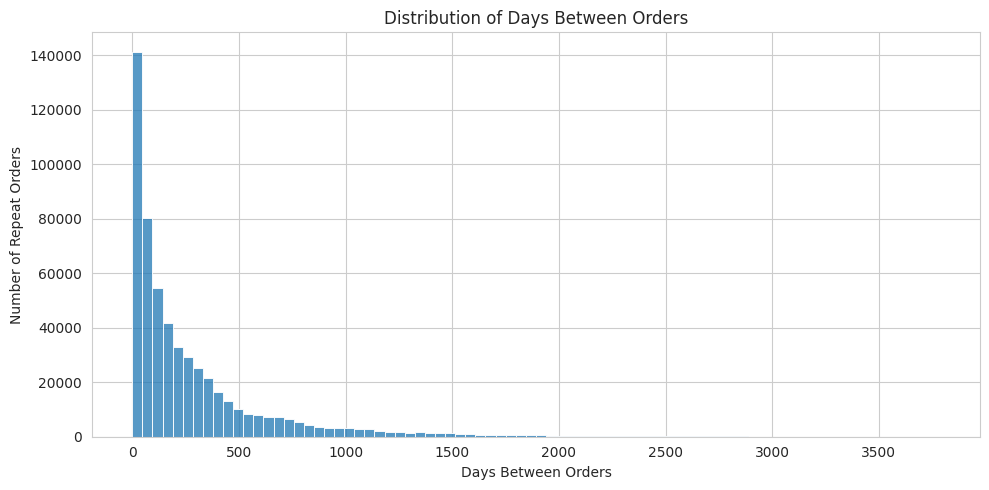

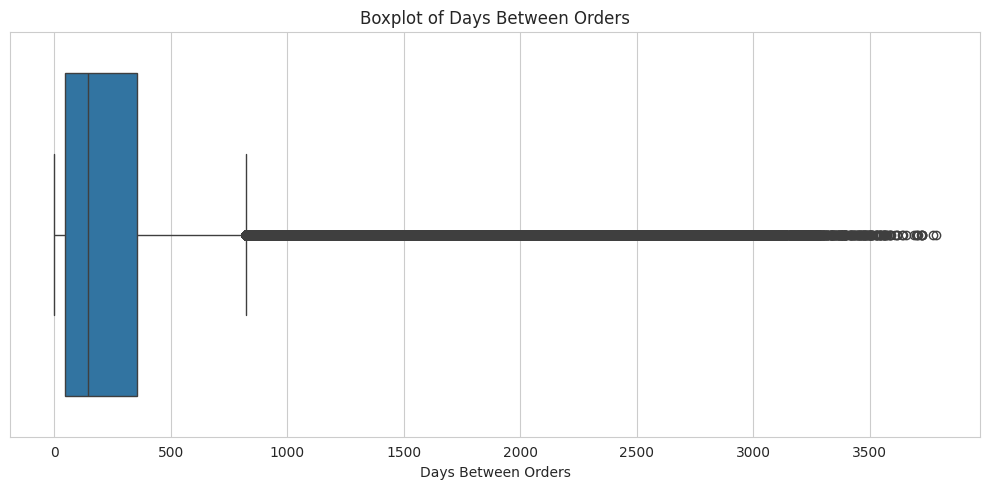

In [ ]:
# =========================================================
# 13.4 REPURCHASE CYCLE ANALYSIS
# Khoảng cách mua lại = ngày đơn hàng hiện tại - ngày đơn hàng trước đó của cùng customer
# =========================================================

order_cycle = fact_order.copy()

order_cycle = order_cycle.sort_values(["customer_id", "order_date", "order_id"])

order_cycle["previous_order_date"] = order_cycle.groupby("customer_id")["order_date"].shift(1)
order_cycle["days_between_orders"] = (
    order_cycle["order_date"] - order_cycle["previous_order_date"]
).dt.days

repurchase_orders = order_cycle[order_cycle["days_between_orders"].notna()].copy()

repurchase_cycle_summary = pd.DataFrame({
    "metric": [
        "repeat_orders",
        "repeat_customers",
        "avg_days_between_orders",
        "median_days_between_orders",
        "p25_days_between_orders",
        "p75_days_between_orders",
        "p90_days_between_orders",
        "min_days_between_orders",
        "max_days_between_orders"
    ],
    "value": [
        len(repurchase_orders),
        repurchase_orders["customer_id"].nunique(),
        repurchase_orders["days_between_orders"].mean(),
        repurchase_orders["days_between_orders"].median(),
        repurchase_orders["days_between_orders"].quantile(0.25),
        repurchase_orders["days_between_orders"].quantile(0.75),
        repurchase_orders["days_between_orders"].quantile(0.90),
        repurchase_orders["days_between_orders"].min(),
        repurchase_orders["days_between_orders"].max()
    ]
})

print_section("REPURCHASE CYCLE SUMMARY")
display(repurchase_cycle_summary)


plt.figure(figsize=(10, 5))
sns.histplot(repurchase_orders["days_between_orders"], bins=80)
plt.title("Distribution of Days Between Orders")
plt.xlabel("Days Between Orders")
plt.ylabel("Number of Repeat Orders")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(x=repurchase_orders["days_between_orders"])
plt.title("Boxplot of Days Between Orders")
plt.xlabel("Days Between Orders")
plt.tight_layout()
plt.show()

Có 67,888 khách hàng mua lặp lại, trên tổng 90,246 khách hàng, tương đương khoảng 75.23%. Đây là tín hiệu tích cực: phần lớn khách hàng không chỉ mua một lần.

Tuy nhiên, chu kỳ mua lại khá dài. Trung bình một khách mất khoảng 285.59 ngày để mua lại, nhưng trung vị chỉ 144 ngày. Sự chênh lệch này cho thấy phân phối khoảng cách mua lại bị lệch phải: nhiều khách hàng có khoảng cách mua lại rất dài, kéo giá trị trung bình lên.

Có thể diễn giải theo chu kỳ:

- 25% lượt mua lại xảy ra trong vòng 46 ngày.
- 50% lượt mua lại xảy ra trong vòng 144 ngày, tương đương gần 5 tháng.
- 75% lượt mua lại xảy ra trong vòng 357 ngày, gần 1 năm.
- 90% lượt mua lại xảy ra trong vòng 733 ngày, hơn 2 năm.

In [ ]:
def plot_barh(df, y_col, x_col, title="", n=15, ascending=False):
    if df.empty:
        print(f"[SKIP] {title}: DataFrame rỗng.")
        return

    plot_df = df.sort_values(x_col, ascending=ascending).head(n)

    plt.figure(figsize=(10, max(5, n * 0.35)))
    sns.barplot(data=plot_df, y=y_col, x=x_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


REGION CLV AND REPURCHASE SUMMARY


,region,customers,total_orders,total_revenue,total_clv,avg_clv,median_clv,avg_revenue_per_customer,avg_orders_per_customer,avg_aov,repeat_customer_rate,avg_days_between_orders,median_days_between_orders,avg_recency_days,churn_1y_rate,customer_share,revenue_share,clv_share
2,West,14741,167642,"3,671,019,033.8800","255,771,706.8371","17,351.0418","6,640.0135","249,034.5997",11.3725,"21,590.1278",0.7869,433.6308,376.6668,"1,125.3922",0.6619,0.1633,0.2341,0.2533
1,East,44721,294612,"7,292,395,107.4000","461,410,843.9130","10,317.5431","5,002.6826","163,064.2228",6.5878,"24,143.8384",0.7758,570.4003,508.8110,"1,254.1671",0.7341,0.4955,0.4650,0.4570
0,Central,30784,184691,"4,720,264,433.8100","292,446,998.6621","9,499.9675","3,829.7390","153,334.9933",5.9996,"25,091.9149",0.7014,611.0463,556.3574,"1,319.4816",0.7459,0.3411,0.3010,0.2897


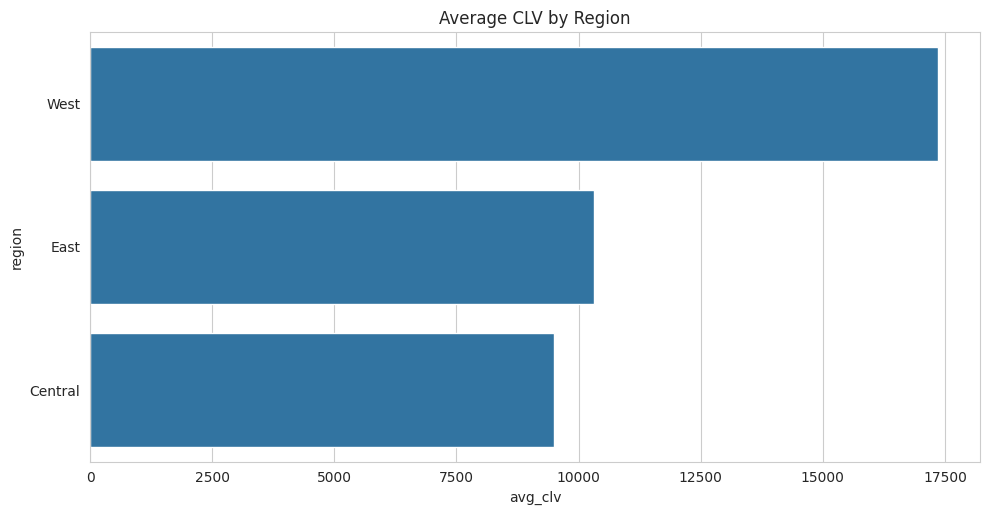

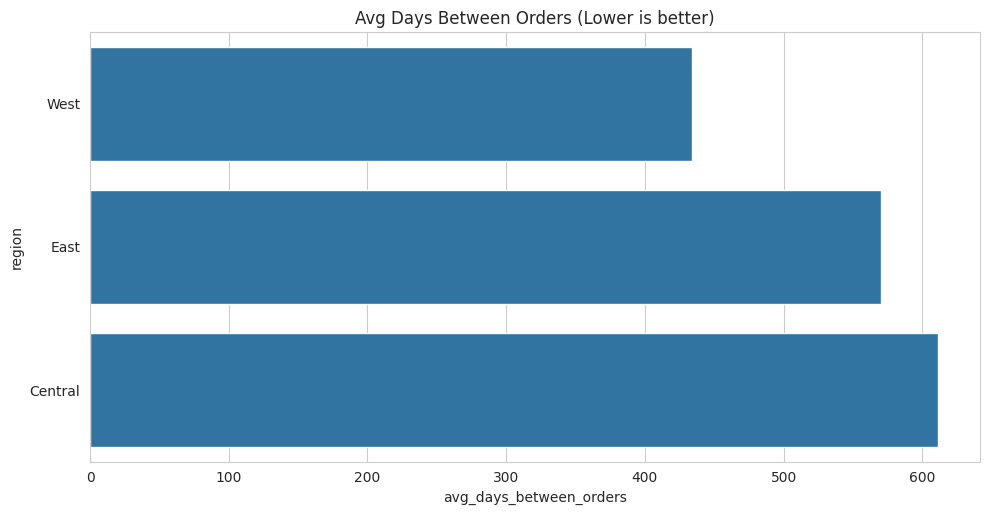

In [ ]:
# =========================================================
# 13.6 REGION-LEVEL CLV AND REPURCHASE ANALYSIS (FIXED)
# =========================================================

# 1. Calculate repurchase cycle metrics at customer level and merge into fact_customer
if 'avg_days_between_orders' not in fact_customer.columns:
    customer_repurchase = (
        repurchase_orders.groupby("customer_id")["days_between_orders"]
        .agg(avg_days_between_orders="mean", median_days_between_orders="median")
        .reset_index()
    )
    fact_customer = fact_customer.merge(customer_repurchase, on="customer_id", how="left")

# 2. Determine region column
region_col_customer = "main_region" if "main_region" in fact_customer.columns else "region"

if region_col_customer not in fact_customer.columns:
    customer_region = (
        fact_order.groupby("customer_id")["region"]
        .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else np.nan)
        .reset_index()
        .rename(columns={"region": "main_region"})
    )
    fact_customer = fact_customer.merge(customer_region, on="customer_id", how="left")
    region_col_customer = "main_region"

# 3. Aggregate by region
region_clv_summary = (
    fact_customer.groupby(region_col_customer, dropna=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_orders=("orders", "sum"),
        total_revenue=("total_revenue_for_clv", "sum"),
        total_clv=("clv", "sum"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median"),
        avg_revenue_per_customer=("total_revenue_for_clv", "mean"),
        avg_orders_per_customer=("orders", "mean"),
        avg_aov=("aov", "mean"),
        repeat_customer_rate=("is_repeat_customer", "mean"),
        avg_days_between_orders=("avg_days_between_orders", "mean"),
        median_days_between_orders=("median_days_between_orders", "mean"),
        avg_recency_days=("recency_days", "mean"),
        churn_1y_rate=("is_churn_1y", "mean")
    )
    .reset_index()
    .rename(columns={region_col_customer: "region"})
)

region_clv_summary["customer_share"] = safe_divide(region_clv_summary["customers"], region_clv_summary["customers"].sum())
region_clv_summary["revenue_share"] = safe_divide(region_clv_summary["total_revenue"], region_clv_summary["total_revenue"].sum())
region_clv_summary["clv_share"] = safe_divide(region_clv_summary["total_clv"], region_clv_summary["total_clv"].sum())

region_clv_summary = region_clv_summary.sort_values("avg_clv", ascending=False)

print_section("REGION CLV AND REPURCHASE SUMMARY")
display(region_clv_summary)

# Visualization
plot_barh(region_clv_summary, y_col="region", x_col="avg_clv", title="Average CLV by Region")
plot_barh(region_clv_summary, y_col="region", x_col="avg_days_between_orders", title="Avg Days Between Orders (Lower is better)", ascending=True)

West là vùng có chất lượng khách hàng tốt nhất. Dù chỉ có 14,741 khách hàng, thấp hơn nhiều so với East và Central, West có CLV trung bình cao nhất, đạt 17,351.04, cao hơn đáng kể so với East và Central. West cũng có số đơn trung bình trên mỗi khách là 11.37 đơn/khách, cao hơn nhiều so với East khoảng 6.59 và Central khoảng 6.00.

Điều này cho thấy khách hàng ở West không chỉ có giá trị cao hơn mà còn mua lại thường xuyên hơn. Đây là vùng nên ưu tiên cho loyalty program, upsell, cross-sell và chăm sóc khách hàng VIP.

East là vùng có quy mô lớn nhất, với 44,721 khách hàng, 294,612 đơn và tổng CLV cao nhất khoảng 461.41 triệu. Tuy nhiên, CLV trung bình của East chỉ khoảng 10,317.54, thấp hơn West. Điều này cho thấy East là thị trường lớn về quy mô nhưng chất lượng khách hàng trung bình chưa bằng West.

Central có CLV trung bình thấp nhất trong ba vùng, khoảng 9,500, đồng thời số đơn trung bình/khách cũng thấp hơn West. Central cần được phân tích thêm về danh mục sản phẩm, tỷ lệ hoàn trả, khuyến mãi, giao hàng hoặc đặc điểm khách hàng để hiểu vì sao giá trị trung bình thấp hơn.

West là vùng có chất lượng khách hàng tốt nhất, phù hợp để tập trung chiến lược giữ chân và tăng giá trị vòng đời. East là vùng có quy mô lớn nhất và tổng CLV cao nhất, nên phù hợp với chiến lược tối ưu hiệu quả marketing và cá nhân hóa theo phân khúc. Central cần được ưu tiên phân tích nguyên nhân CLV thấp hơn để cải thiện lợi nhuận trên mỗi khách hàng.

In [ ]:
# =========================================================
# 13.7 REGION x CLV SEGMENT ANALYSIS
# =========================================================

customer_region_clv = fact_customer.copy()

if "clv_percentile_segment" not in customer_region_clv.columns:
    customer_region_clv["clv_percentile_rank"] = customer_region_clv["clv"].rank(pct=True, method="first")
    customer_region_clv["clv_percentile_segment"] = pd.cut(
        customer_region_clv["clv_percentile_rank"],
        bins=[0, 0.20, 0.40, 0.60, 0.80, 1.000001],
        labels=[
            "Bottom 20%",
            "Low-Mid 20%",
            "Middle 20%",
            "High 20%",
            "Top 20% / VIP"
        ],
        include_lowest=True
    )

region_col = region_col_customer

region_clv_segment_summary = (
    customer_region_clv.groupby([region_col, "clv_percentile_segment"], observed=False, dropna=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("total_revenue_for_clv", "sum"),
        total_clv=("clv", "sum"),
        avg_clv=("clv", "mean"),
        avg_orders=("orders", "mean"),
        avg_days_between_orders=("avg_days_between_orders", "mean"),
        churn_1y_rate=("is_churn_1y", "mean") if "is_churn_1y" in customer_region_clv.columns else ("orders", "mean"),
        promo_usage_rate=("promo_usage_rate", "mean") if "promo_usage_rate" in customer_region_clv.columns else ("orders", "mean")
    )
    .reset_index()
    .rename(columns={region_col: "region"})
)

# Tỷ trọng khách của từng phân vị trong mỗi vùng
region_total_customers = (
    customer_region_clv.groupby(region_col)["customer_id"]
    .nunique()
    .reset_index()
    .rename(columns={region_col: "region", "customer_id": "region_customers"})
)

region_clv_segment_summary = region_clv_segment_summary.merge(
    region_total_customers,
    on="region",
    how="left"
)

region_clv_segment_summary["segment_customer_share_in_region"] = safe_divide(
    region_clv_segment_summary["customers"],
    region_clv_segment_summary["region_customers"]
)

print_section("REGION x CLV PERCENTILE SEGMENT SUMMARY")
display(region_clv_segment_summary)


plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_clv_segment_summary,
    x="region",
    y="segment_customer_share_in_region",
    hue="clv_percentile_segment"
)
plt.title("CLV Segment Customer Share within Each Region")
plt.xlabel("Region")
plt.ylabel("Customer Share within Region")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Một số kết quả đáng chú ý:

Central có 5,373 khách thuộc Top 20% / VIP.

East có số khách hàng lớn nhất nên nhiều khả năng cũng có số lượng VIP lớn nhất về tuyệt đối.

West tuy quy mô nhỏ hơn nhưng trong bảng region summary lại có CLV trung bình cao nhất, cho thấy tỷ trọng khách giá trị cao ở West có thể tốt hơn hoặc khách West có hành vi mua lại tốt hơn.



# V. Phân tích doanh thu

## 5.1. Phân tích Tính Thời vụ (Seasonality Analysis)
Phần này tính toán Seasonal Index để xác định tháng nào thường có doanh thu cao hơn mức trung bình và sử dụng Heatmap để quan sát sự thay đổi theo từng năm.

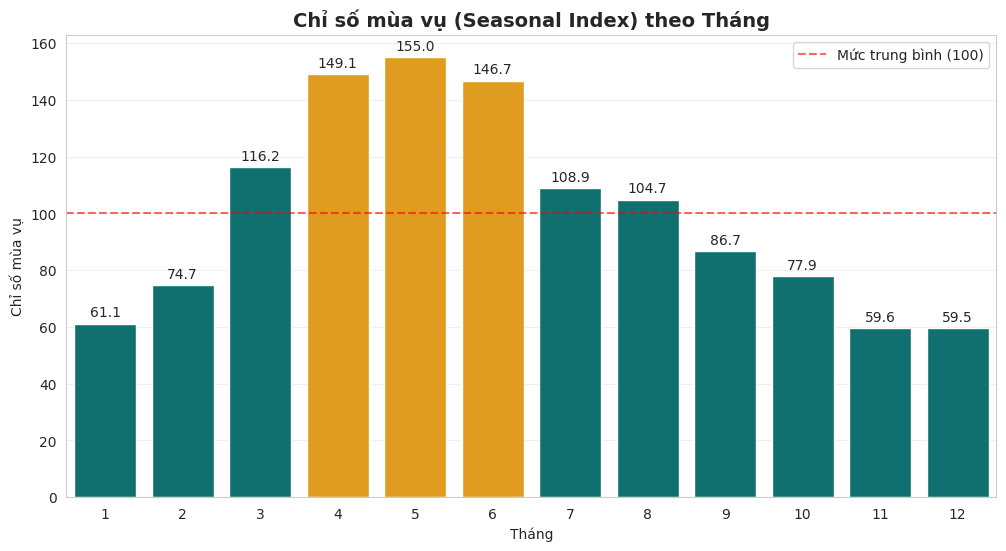

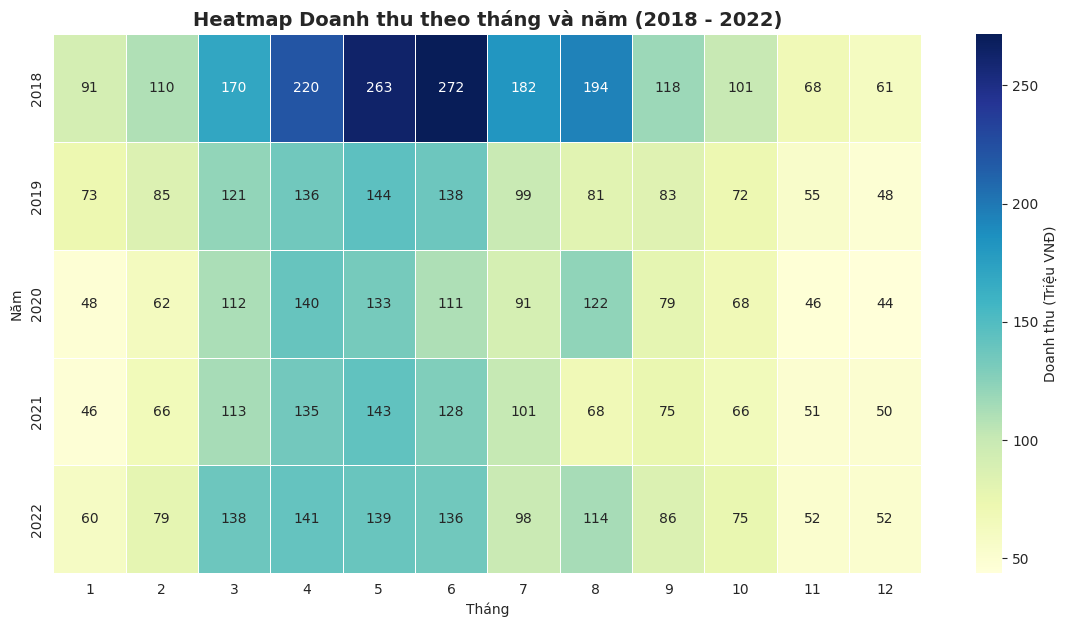

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Chuẩn bị dữ liệu theo tháng và năm
sales_monthly = fact_sales.groupby(['order_year', 'order_month'])['gross_revenue_before_discount'].sum().reset_index()

# 2. Tính Seasonal Index
# Trung bình doanh thu của từng tháng qua các năm
monthly_avg = sales_monthly.groupby('order_month')['gross_revenue_before_discount'].mean()
# Trung bình chung của tất cả các tháng
grand_avg = monthly_avg.mean()
# Seasonal Index = (Tháng trung bình / Trung bình chung) * 100
seasonal_index = (monthly_avg / grand_avg) * 100

# 3. Vẽ biểu đồ Seasonal Index (Cột + Highlight Top 3)
plt.figure(figsize=(12, 6))
colors = ['teal' if (val not in seasonal_index.nlargest(3).values) else 'orange' for val in seasonal_index.values]
ax = sns.barplot(x=seasonal_index.index, y=seasonal_index.values, palette=colors, hue=seasonal_index.index, legend=False)

# Hiển thị giá trị trên đầu cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.axhline(100, color='red', linestyle='--', alpha=0.6, label='Mức trung bình (100)')

plt.title('Chỉ số mùa vụ (Seasonal Index) theo Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Chỉ số mùa vụ')
plt.xticks(range(0, 12), labels=range(1, 13))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Vẽ Heatmap doanh thu (2018 - 2022) - Đơn vị Triệu VNĐ
heatmap_data = sales_monthly[(sales_monthly['order_year'] >= 2018) & (sales_monthly['order_year'] <= 2022)].copy()
# Chuyển sang đơn vị triệu đồng
heatmap_data['gross_revenue_before_discount_m'] = heatmap_data['gross_revenue_before_discount'] / 1_000_000
heatmap_pivot = heatmap_data.pivot(index='order_year', columns='order_month', values='gross_revenue_before_discount_m')

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_pivot, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Doanh thu (Triệu VNĐ)'})
plt.title('Heatmap Doanh thu theo tháng và năm (2018 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.show()

## 5.2. Doanh thu và AOV

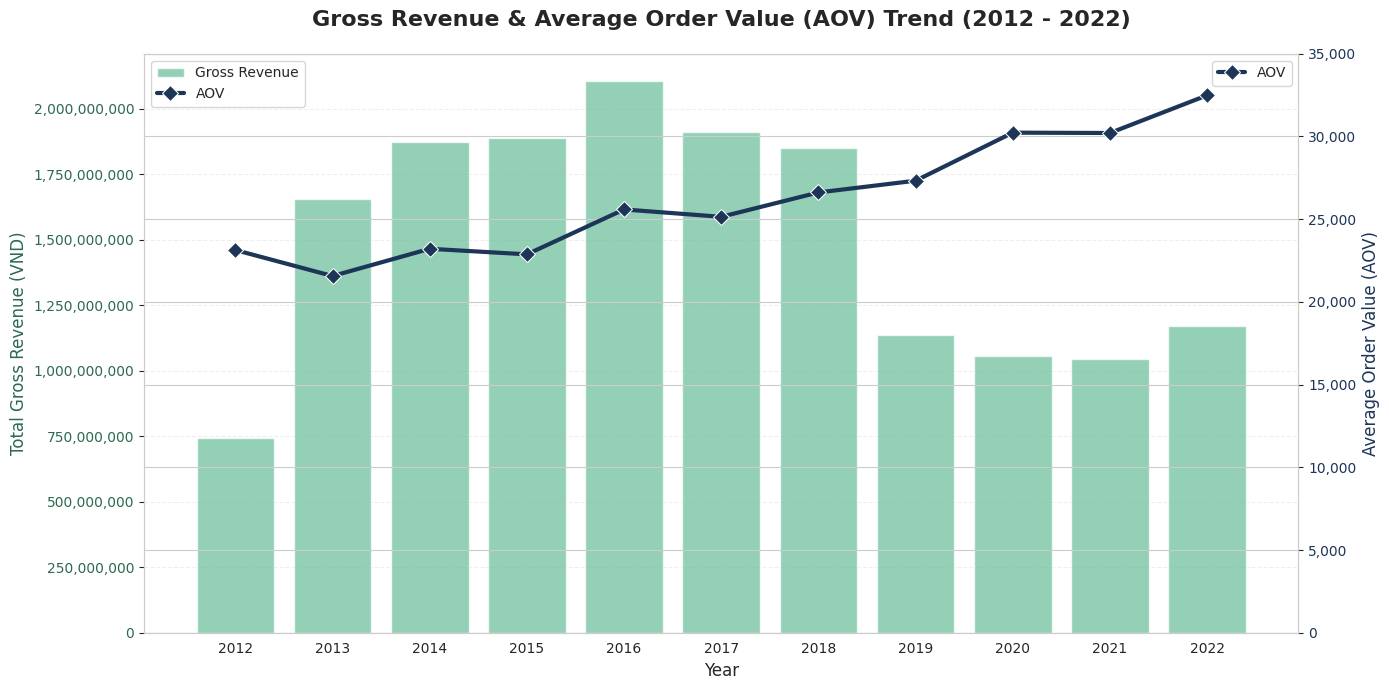

,order_year,total_gross_revenue,total_orders,aov
0,2012,"741,497,748","32,051","23,134.93"
1,2013,"1,657,169,417","76,849","21,563.97"
2,2014,"1,871,845,883","80,645","23,210.94"
3,2015,"1,889,933,827","82,622","22,874.46"
4,2016,"2,104,640,678","82,247","25,589.27"
5,2017,"1,911,164,325","76,010","25,143.59"
6,2018,"1,850,122,456","69,510","26,616.64"
7,2019,"1,136,801,442","41,601","27,326.30"
8,2020,"1,054,512,159","34,881","30,231.71"
9,2021,"1,043,039,820","34,525","30,211.15"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Prepare data from fact_order (2012-2022)
yearly_sales = fact_order[
    (fact_order['order_year'] >= 2012) & (fact_order['order_year'] <= 2022)
].groupby('order_year').agg(
    total_gross_revenue=('gross_revenue_before_discount', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# 2. Calculate AOV
yearly_sales['aov'] = yearly_sales['total_gross_revenue'] / yearly_sales['total_orders']

# 3. Setup the visualization
fig, ax1 = plt.subplots(figsize=(14, 7))

# Main Axis: Gross Revenue (Bar chart)
sns.barplot(data=yearly_sales, x='order_year', y='total_gross_revenue', ax=ax1, color='#57cc99', alpha=0.7, label='Gross Revenue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Gross Revenue (VND)', fontsize=12, color='#2d6a4f')
ax1.tick_params(axis='y', labelcolor='#2d6a4f')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Secondary Axis: AOV (Line chart)
ax2 = ax1.twinx()
sns.lineplot(data=yearly_sales, x=ax1.get_xticks(), y='aov', ax=ax2, marker='D', color='#1d3557', linewidth=3, markersize=8, label='AOV')
ax2.set_ylabel('Average Order Value (AOV)', fontsize=12, color='#1d3557')
ax2.tick_params(axis='y', labelcolor='#1d3557')
ax2.set_ylim(0, 35000) # Set AOV axis limits as requested
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Gross Revenue & Average Order Value (AOV) Trend (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Display summary table
display(yearly_sales.style.format({
    'total_gross_revenue': '{:,.0f}',
    'total_orders': '{:,.0f}',
    'aov': '{:,.2f}'
}))

## 5.3. Phân tích khách hàng mới

In [ ]:
import pandas as pd
import numpy as np

# 1. Xác định ngày mua đầu tiên của mỗi khách hàng và năm gia nhập (Cohort Year)
customer_first_purchase = fact_order.groupby('customer_id').agg(
    first_purchase_date=('order_date', 'min')
).reset_index()
customer_first_purchase['cohort_year'] = customer_first_purchase['first_purchase_date'].dt.year

# 2. Lấy tất cả các đơn hàng và gắn thông tin ngày mua đầu tiên vào
all_orders = fact_order[['customer_id', 'order_date', 'order_id']].copy()
all_orders = all_orders.merge(customer_first_purchase, on='customer_id')

# 3. Tính khoảng cách từ các đơn hàng sau đến ngày mua đầu tiên (đơn hàng đầu tiên có diff = 0)
all_orders['days_since_first'] = (all_orders['order_date'] - all_orders['first_purchase_date']).dt.days

# 4. Xác định xem khách hàng có quay lại trong vòng 1 năm (1-365 ngày) và 2 năm (1-730 ngày) không
# Lưu ý: Không tính đơn hàng đầu tiên (days_since_first == 0)
repeat_behavior = all_orders[all_orders['days_since_first'] > 0].groupby('customer_id').agg(
    min_days_to_repeat=('days_since_first', 'min')
).reset_index()

# 5. Kết hợp lại với danh sách khách hàng mới ban đầu
cohort_analysis = customer_first_purchase.merge(repeat_behavior, on='customer_id', how='left')

# Đánh giá flag quay lại
cohort_analysis['repeat_1y'] = (cohort_analysis['min_days_to_repeat'] <= 365).astype(int)
cohort_analysis['repeat_2y'] = (cohort_analysis['min_days_to_repeat'] <= 730).astype(int)

# 6. Tổng hợp theo năm gia nhập (Cohort Year)
annual_cohort_metrics = cohort_analysis.groupby('cohort_year').agg(
    new_customers=('customer_id', 'count'),
    repeated_1y=('repeat_1y', 'sum'),
    repeated_2y=('repeat_2y', 'sum')
).reset_index()

annual_cohort_metrics['actual_repeat_rate_1y'] = (annual_cohort_metrics['repeated_1y'] / annual_cohort_metrics['new_customers']) * 100
annual_cohort_metrics['actual_repeat_rate_2y'] = (annual_cohort_metrics['repeated_2y'] / annual_cohort_metrics['new_customers']) * 100

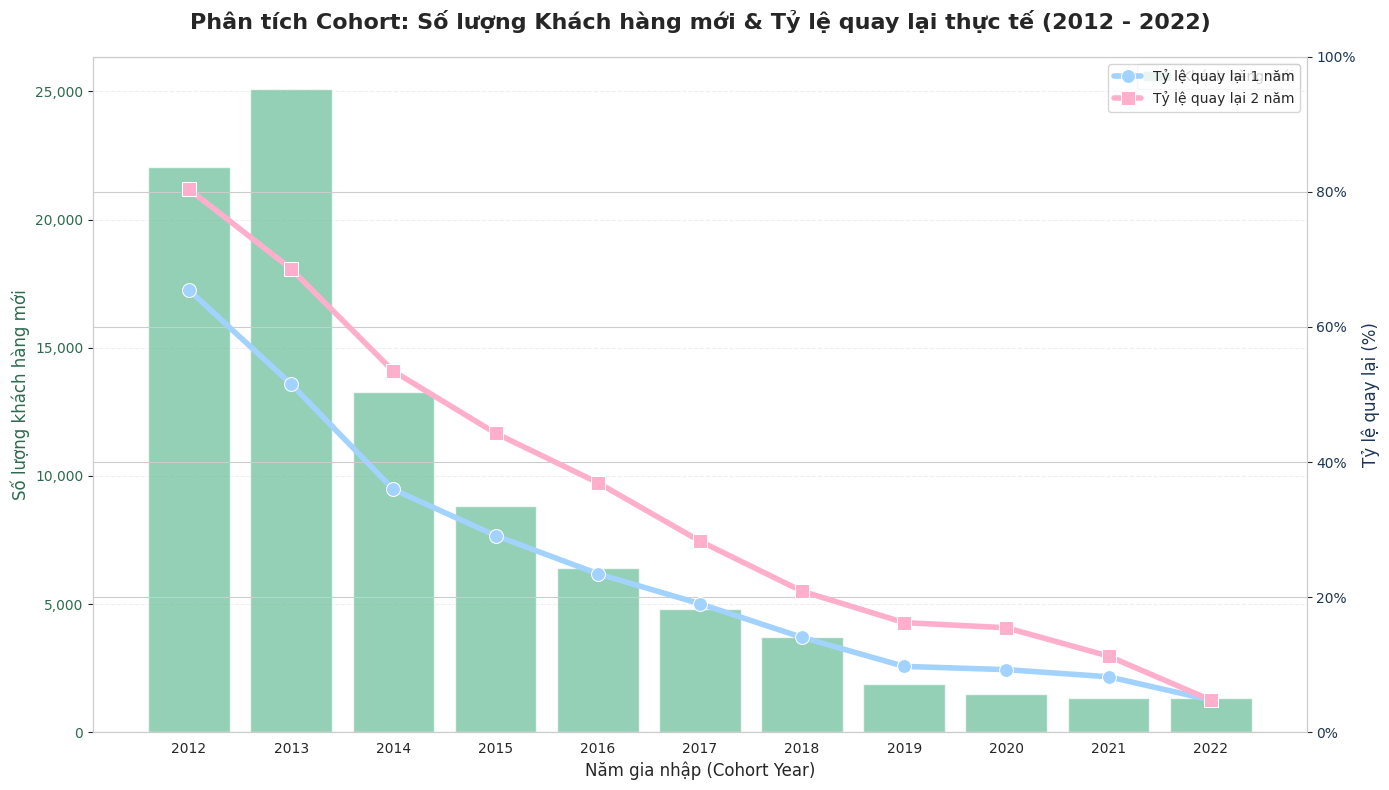

,cohort_year,new_customers,actual_repeat_rate_1y,actual_repeat_rate_2y
0,2012,"22,068",65.46%,80.38%
1,2013,"25,099",51.53%,68.58%
2,2014,"13,293",35.94%,53.45%
3,2015,"8,828",29.11%,44.27%
4,2016,"6,392",23.47%,36.95%
5,2017,"4,789",19.02%,28.29%
6,2018,"3,717",14.04%,20.88%
7,2019,"1,898",9.75%,16.23%
8,2020,"1,500",9.27%,15.47%
9,2021,"1,340",8.21%,11.27%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Tính toán chính xác theo Cohort (đã thực hiện ở cell trước, lấy kết quả để vẽ)
# annual_cohort_metrics chứa: cohort_year, actual_repeat_rate_1y, actual_repeat_rate_2y, new_customers

plot_data_final = annual_cohort_metrics[annual_cohort_metrics['cohort_year'] <= 2022].copy()

# 2. Thiết lập biểu đồ
fig, ax1 = plt.subplots(figsize=(14, 8))

# Trục chính: Số lượng khách hàng mới (Cột - Màu xanh mint)
sns.barplot(data=plot_data_final, x='cohort_year', y='new_customers', ax=ax1, color='#57cc99', alpha=0.7, label='Khách hàng mới')
ax1.set_xlabel('Năm gia nhập (Cohort Year)', fontsize=12)
ax1.set_ylabel('Số lượng khách hàng mới', fontsize=12, color='#2d6a4f')
ax1.tick_params(axis='y', labelcolor='#2d6a4f')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Trục phụ: Tỷ lệ quay lại (Đường)
ax2 = ax1.twinx()

# Đường 1 năm (Xanh pastel)
sns.lineplot(data=plot_data_final, x=ax1.get_xticks(), y='actual_repeat_rate_1y', ax=ax2,
             marker='o', color='#a2d2ff', linewidth=4, markersize=10, label='Tỷ lệ quay lại 1 năm')

# Đường 2 năm (Hồng pastel)
sns.lineplot(data=plot_data_final, x=ax1.get_xticks(), y='actual_repeat_rate_2y', ax=ax2,
             marker='s', color='#ffafcc', linewidth=4, markersize=10, label='Tỷ lệ quay lại 2 năm')

# Định dạng trục tỷ lệ %
ax2.set_ylabel('Tỷ lệ quay lại (%)', fontsize=12, color='#1d3557')
ax2.tick_params(axis='y', labelcolor='#1d3557')
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())

plt.title('Phân tích Cohort: Số lượng Khách hàng mới & Tỷ lệ quay lại thực tế (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Gộp Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu chuẩn xác
display(plot_data_final[['cohort_year', 'new_customers', 'actual_repeat_rate_1y', 'actual_repeat_rate_2y']].style.format({
    'new_customers': '{:,.0f}',
    'actual_repeat_rate_1y': '{:.2f}%',
    'actual_repeat_rate_2y': '{:.2f}%'
}))

### **Chú thích về Cách tính Tỷ lệ Quay lại (Repeat Rate)**

Trong biểu đồ trên, tỷ lệ quay lại được xác định dựa trên dữ liệu rời bỏ (Churn) với công thức:

*   **Công thức:** `Tỷ lệ Quay lại = 1 - Tỷ lệ Rời bỏ (Churn Rate)`
*   **Định nghĩa:**
    *   **Tỷ lệ 1 năm:** Khách hàng có ít nhất một giao dịch phát sinh trong vòng 365 ngày kể từ lần mua gần nhất.
    *   **Tỷ lệ 2 năm:** Khách hàng có ít nhất một giao dịch phát sinh trong vòng 730 ngày kể từ lần mua gần nhất.
*   **Dữ liệu:** Chỉ số được tính toán tại thời điểm chốt (cuối mỗi năm) dựa trên dữ liệu lịch sử từ bảng `monthly_churn_all`.

## 5.4. Phân tích theo độ tuổi (dẫn chứng cho đề xuất)

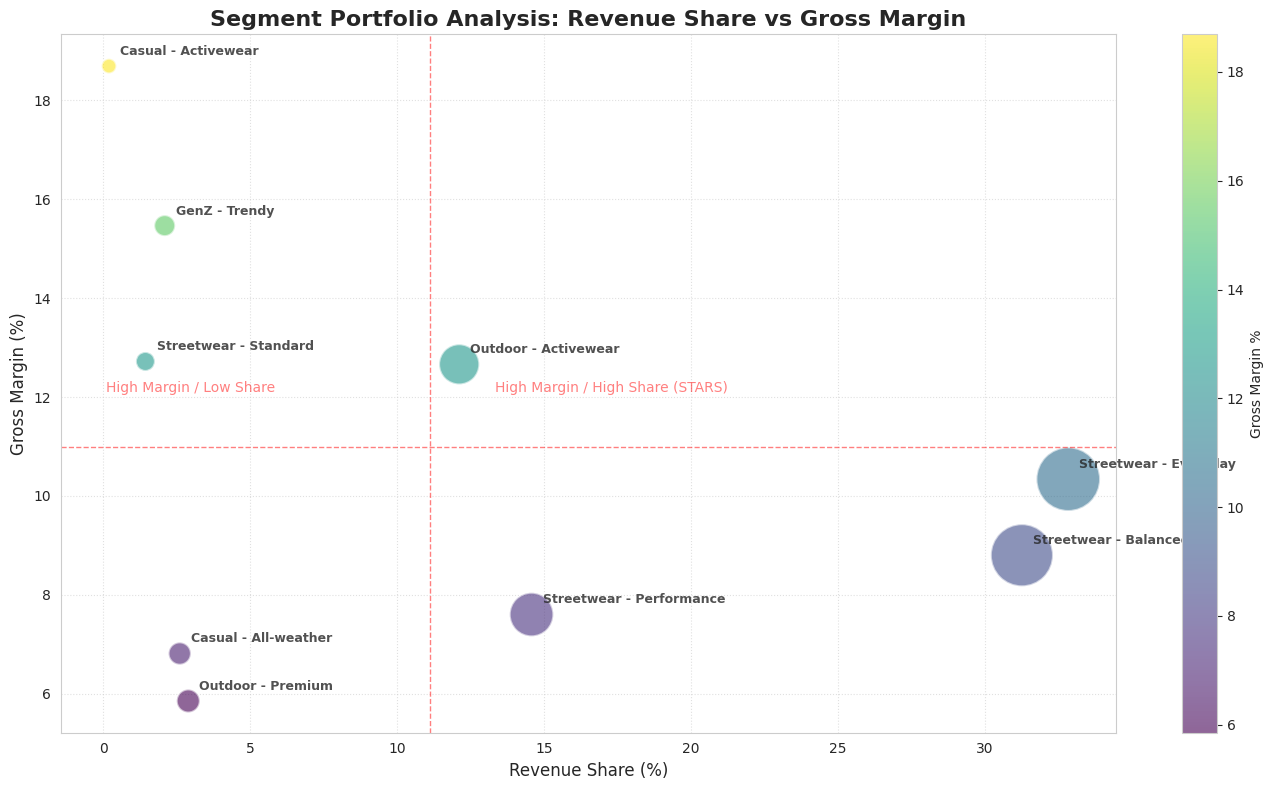

,category,segment,revenue,gross_profit,revenue_share_pct,gm_pct,label
6,Streetwear,Everyday,"5,147,454,917","532,174,759",32.83%,10.34%,Streetwear - Everyday
5,Streetwear,Balanced,"4,900,317,966","431,236,061",31.25%,8.80%,Streetwear - Balanced
7,Streetwear,Performance,"2,285,029,332","173,693,837",14.57%,7.60%,Streetwear - Performance
3,Outdoor,Activewear,"1,899,184,896","240,447,866",12.11%,12.66%,Outdoor - Activewear
4,Outdoor,Premium,"454,211,901","26,586,226",2.90%,5.85%,Outdoor - Premium
1,Casual,All-weather,"408,765,115","27,849,082",2.61%,6.81%,Casual - All-weather
2,GenZ,Trendy,"328,710,176","50,836,377",2.10%,15.47%,GenZ - Trendy
8,Streetwear,Standard,"225,674,884","28,702,855",1.44%,12.72%,Streetwear - Standard
0,Casual,Activewear,"31,520,078","5,891,683",0.20%,18.69%,Casual - Activewear


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tổng hợp dữ liệu theo Category + Segment từ fact_sales có sẵn
portfolio_data = (
    fact_sales
    .groupby(["category", "segment"], as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum")
    )
)

# 2. Tính toán các chỉ số Revenue Share và Gross Margin %
portfolio_data["revenue_share_pct"] = portfolio_data["revenue"] / portfolio_data["revenue"].sum() * 100
portfolio_data["gm_pct"] = (portfolio_data["gross_profit"] / portfolio_data["revenue"]) * 100
portfolio_data["label"] = portfolio_data["category"] + " - " + portfolio_data["segment"]

# 3. Tính toán đường trung bình để phân loại ma trận
avg_revenue_share = portfolio_data["revenue_share_pct"].mean()
avg_gm = portfolio_data["gm_pct"].mean()

# 4. Vẽ Bubble Scatter Plot
plt.figure(figsize=(14, 8))

# Sử dụng scatter với kích thước bóng dựa trên doanh thu
sc = plt.scatter(
    portfolio_data["revenue_share_pct"],
    portfolio_data["gm_pct"],
    s=portfolio_data["revenue"] / portfolio_data["revenue"].max() * 2000 + 100,
    alpha=0.6,
    c=portfolio_data["gm_pct"],
    cmap="viridis",
    edgecolors="w",
    linewidth=1.5
)

# Gắn nhãn cho từng điểm
for _, row in portfolio_data.iterrows():
    plt.annotate(
        row["label"],
        (row["revenue_share_pct"], row["gm_pct"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight='bold',
        alpha=0.8
    )

# Vẽ các đường trung bình chia 4 vùng
plt.axhline(avg_gm, color='red', linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(avg_revenue_share, color='red', linestyle="--", linewidth=1, alpha=0.5)

# Chú thích các vùng
plt.text(avg_revenue_share*1.2, avg_gm*1.1, "High Margin / High Share (STARS)", color='red', alpha=0.5, fontsize=10)
plt.text(0.1, avg_gm*1.1, "High Margin / Low Share", color='red', alpha=0.5, fontsize=10)

# Định dạng biểu đồ
plt.title("Segment Portfolio Analysis: Revenue Share vs Gross Margin", fontsize=16, fontweight='bold')
plt.xlabel("Revenue Share (%)", fontsize=12)
plt.ylabel("Gross Margin (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Thêm colorbar để thể hiện mức độ Margin
cbar = plt.colorbar(sc)
cbar.set_label('Gross Margin %')

plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu tóm tắt
display(portfolio_data.sort_values("revenue", ascending=False).style.format({
    'revenue': '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'revenue_share_pct': '{:.2f}%',
    'gm_pct': '{:.2f}%'
}))

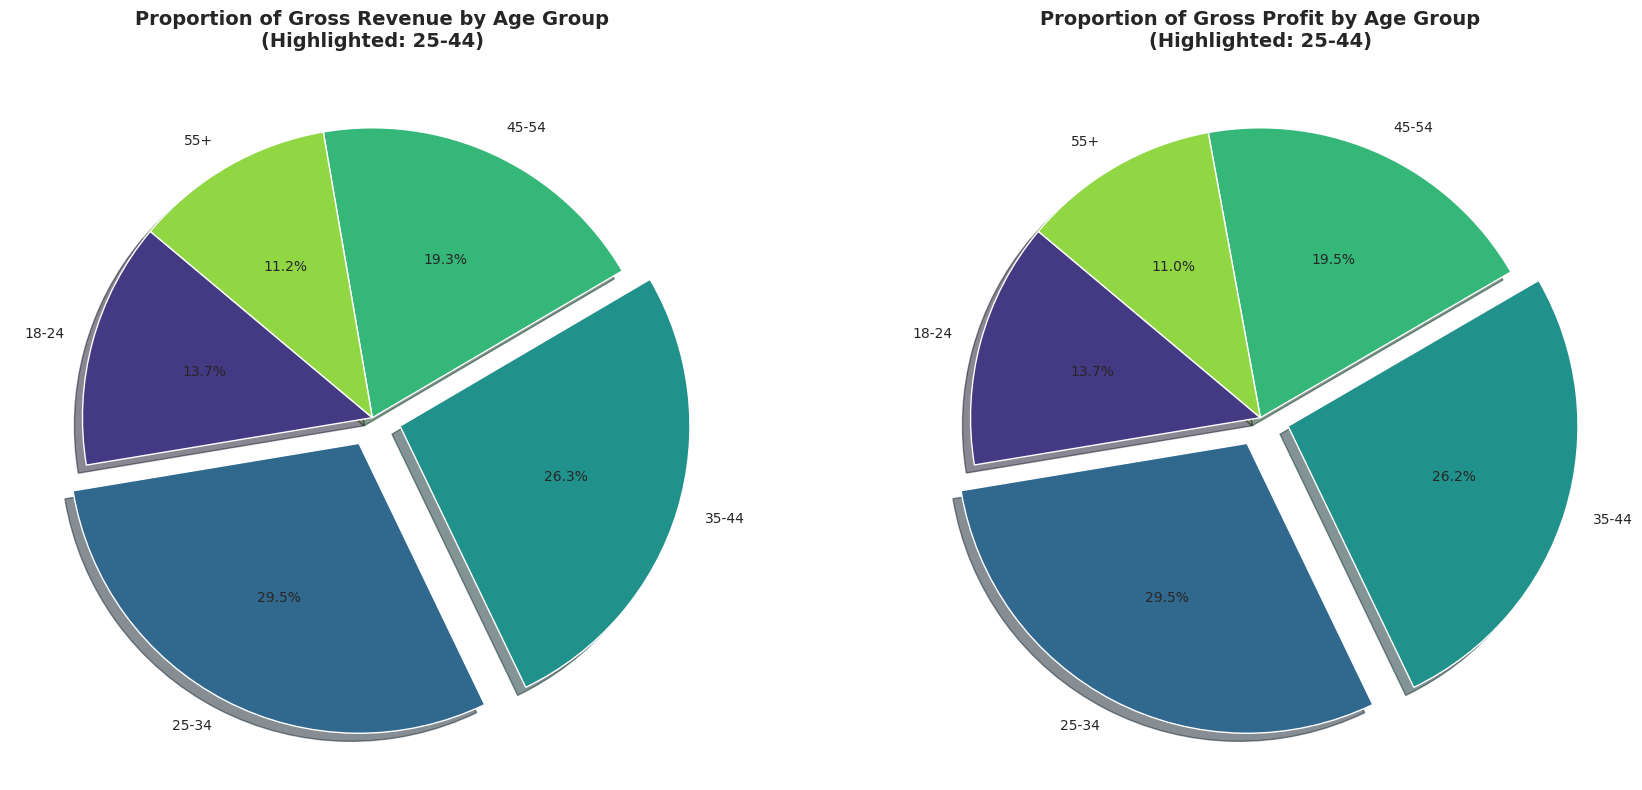

,age_group,total_revenue,total_profit
0,18-24,"2,255,624,744","208,187,640"
1,25-34,"4,850,426,456","448,092,115"
2,35-44,"4,323,232,921","398,246,707"
3,45-54,"3,163,670,019","295,819,805"
4,55+,"1,837,522,445","167,072,480"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate Revenue and Profit by Age Group
age_contribution = fact_sales.groupby('age_group').agg(
    total_revenue=('gross_revenue_before_discount', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

# 2. Identify slices to highlight (explode)
# We want to highlight '25-34' and '35-44'
explode = [0.1 if age in ['25-34', '35-44'] else 0 for age in age_contribution['age_group']]

# 3. Setup colors
colors = sns.color_palette("viridis", len(age_contribution))

# 4. Visualization: Two Pie Charts side-by-side with highlighting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Pie Chart for Gross Revenue
ax1.pie(
    age_contribution['total_revenue'],
    labels=age_contribution['age_group'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    wedgeprops={'edgecolor': 'white'}
)
ax1.set_title('Proportion of Gross Revenue by Age Group\n(Highlighted: 25-44)', fontsize=14, fontweight='bold')

# Pie Chart for Gross Profit
ax2.pie(
    age_contribution['total_profit'],
    labels=age_contribution['age_group'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    wedgeprops={'edgecolor': 'white'}
)
ax2.set_title('Proportion of Gross Profit by Age Group\n(Highlighted: 25-44)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Display data table
display(age_contribution.style.format({
    'total_revenue': '{:,.0f}',
    'total_profit': '{:,.0f}'
}))